In [1]:
import torch
import torch.nn as nn
import hdbscan
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA
import os
import sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)
from sklearn.metrics import davies_bouldin_score

from src.data.load_cifar100 import get_cifar100_loaders, create_and_load_subset
from src.models.autoencoder import Autoencoder
from src.data.load_cifar10 import get_cifar10_loaders
from src.models.cmae import CMAE
from src.models.masked_autoencoder import  MAE
from sklearn.manifold import TSNE
import torch.nn.functional as F
from sklearn.preprocessing import normalize

# Load pretrained model

In [2]:
def load_trained_model(model_path, model_type='autoencoder'):
    """
    Wczytanie wytrenowanego modelu

    Args:
        model_path: Ścieżka do pliku .pt
         model_type: "autoencoder', 'cmae' lub 'mae'

    Returns:
        model, checkpoint (słownik z metadanymi)
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Nie znaleziono pliku: {model_path}")

    # wczytanie checkpointa
    checkpoint = torch.load(model_path, map_location=device)

    # ładowanie modelu
    latent_dim = checkpoint.get('latent_dim', 256)  # domyślnie 256
    if model_type.lower() == 'cmae':
        model = CMAE(latent_dim=latent_dim).to(device)
    elif model_type.lower() == 'mae':
        model = MAE(latent_dim=latent_dim).to(device)
    elif model_type.lower() == 'autoencoder':
        model = Autoencoder(latent_dim=latent_dim).to(device)
    else:
        raise ValueError("model_type musi być: 'cmae', 'mae' lub 'autoencoder'")

    # ładowanie wag
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"Model załadowany")
    print(f"Epoka: {checkpoint['epoch']}")
    print(f"Train Loss: {checkpoint['train_loss']:.6f}")
    print(f"Val Loss: {checkpoint['val_loss']:.6f}")
    print(f"Latent Dim: {latent_dim}\n")

    return model, checkpoint

# Ekstrakcja cech

In [3]:
def extract_features(model, dataloader):
    """
    Wyciąga wektory cech z encodera

    Args:
        model: Autoencoder, MAE lub CMAE
        dataloader: DataLoader z danymi

    Returns:
        features: numpy array [N, latent_dim]
        labels: numpy array [N]
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            images = images.to(device)

            if hasattr(model, 'online_encoder'):
                # CMAE
                features = model.online_encoder(images)
            
            elif hasattr(model, 'encoder'):
                # MAE oraz Autoencoder (oba mają self.encoder)
                features = model.encoder(images)
            
            else:
                raise AttributeError("Model nie ma atrybutu 'encoder' ani 'online_encoder'")


            # flattenujemy cechy -- [B, D, 1, 1] -> [B, D]
            if len(features.size()) > 2:
                features = features.view(features.size(0), -1)
            # dostajemy tylko cechy
            # features = model.encode(images)  # [batch_size, latent_dim]
            if batch_idx == 0:  # sprawdzenie
                print(f"Features: {features.size()}")

            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())


    features = np.concatenate(all_features, axis=0)
    labels = np.concatenate(all_labels, axis=0) # do ocenienia klasteryzacji


    print(f"Wyciągnięto cechy: {features.shape}")
    # print(f"Klasy {labels[:5]}") #sprawdzenie

    return features, labels

# Klasteryzacja

In [4]:
def clustering(features, labels, n_clusters=10, pca_dim=50):
    """
    Klasteryzacja używając K-means i HDBSCAN
    
    Args:
        features: numpy array [N, latent_dim]
        labels: numpy array [N] - prawdziwe etykiety
        n_clusters: liczba klastrów dla K-means
    
    Returns:
        cluster_ids: numpy array [N] - przypisanie do klastrów (K-means)
        kmeans: obiekt KMeans
        metrics: słownik z metrykami K-means
        metrics_hdb: słownik z metrykami HDBSCAN
    """

    # normalizacja wektora cech
    features_normalized = normalize(features,norm='l2')

    # zmniejszenie wymiarowości cech do 50 z 256
    if features_normalized.shape[1] > pca_dim:
        pca = PCA(n_components=pca_dim, random_state=42)
        features_reduced = pca.fit_transform(features_normalized)
    else:
        features_reduced = features_normalized


    # # HDBSCAN
    # clusterer = hdbscan.HDBSCAN(
    #     min_cluster_size=n_clusters,
    #     min_samples=5,
    #     cluster_selection_method='eom',
    #     allow_single_cluster=True,
    #     metric='euclidean',
    #     algorithm='best',
    #     leaf_size=30
    # )
    # cluster_ids_hdb = clusterer.fit_predict(features_reduced)
    #


    # K-means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10, verbose=0)
    cluster_ids = kmeans.fit_predict(features_reduced)
    
    # Metryki K-means
    nmi = normalized_mutual_info_score(labels, cluster_ids)
    ari = adjusted_rand_score(labels, cluster_ids)
    silhouette = silhouette_score(features, cluster_ids)
    dbi = davies_bouldin_score(features, cluster_ids)

    
    metrics = {
        'nmi': nmi,
        'ari': ari,
        'silhouette': silhouette,
        'dbi' : dbi,
        'n_clusters': n_clusters,
        'inertia': kmeans.inertia_
    }
    
    print("=== K-means ===")
    print(f"NMI (Normalized Mutual Information): {nmi:.4f}")
    print(f"ARI (Adjusted Rand Index): {ari:.4f}")
    print(f"DBI {dbi:.4f}")

    print(f"Silhouette: {silhouette:.4f}")
    print(f"Inertia: {kmeans.inertia_:.2f}\n")
    
    # # Metryki HDBSCAN
    # nmi_hdb = normalized_mutual_info_score(labels, cluster_ids_hdb)
    # ari_hdb = adjusted_rand_score(labels, cluster_ids_hdb)
    # n_clusters_hdb = len(set(cluster_ids_hdb)) - (1 if -1 in cluster_ids_hdb else 0)
    # n_noise = list(cluster_ids_hdb).count(-1)
    # 
    # metrics_hdb = {
    #     'nmi': nmi_hdb,
    #     'ari': ari_hdb,
    #     'n_clusters': n_clusters_hdb,
    #     'n_noise': n_noise
    # }
    # 
    # print(f"NMI (Normalized Mutual Information): {nmi_hdb:.4f}")
    # print(f"ARI (Adjusted Rand Index): {ari_hdb:.4f}")
    # print(f"Liczba znalezionych klastrów: {n_clusters_hdb}")
    # print(f"Liczba punktów noise: {n_noise}\n")
    
    return cluster_ids, kmeans, metrics

# Wizualizacja klastrów

In [5]:
def visualize_clusters(features, cluster_ids, labels, save_path):
    """
    Pokazanie klastrow w 2D (PCA)
    """

    pca = PCA(n_components=2, random_state=42)
    features_2d = pca.fit_transform(features)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # klastry k-means
    scatter1 = ax1.scatter(features_2d[:, 0], features_2d[:, 1],
                          c=cluster_ids, cmap='tab10', alpha=0.6, s=3)
    ax1.set_title('K-means Clusters', fontsize=14, fontweight='bold')
    plt.colorbar(scatter1, ax=ax1, label='Cluster ID')

    # etykeity z datasetu

    scatter2 = ax2.scatter(features_2d[:, 0], features_2d[:, 1],
                          c=labels, cmap='tab10', alpha=0.6, s=3)
    ax2.set_title('True Labels', fontsize=14, fontweight='bold')
    plt.colorbar(scatter2, ax=ax2, label='Class ID')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    plt.close()



def visualize_clusters_tsne(features, cluster_labels, true_labels, save_path=None):
    """
    Wizualizacja klastrów za pomocą t-SNE
    """

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    features_2d = tsne.fit_transform(features)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Wizualizacja z przypisaniami z K-Means
    scatter1 = axes[0].scatter(features_2d[:, 0], features_2d[:, 1],
                               c=cluster_labels, cmap='tab10', s=5, alpha=0.6)
    axes[0].set_title('K-Means Cluster Assignments')
    axes[0].set_xlabel('t-SNE Component 1')
    axes[0].set_ylabel('t-SNE Component 2')
    plt.colorbar(scatter1, ax=axes[0])

    # Wizualizacja z prawdziwymi etykietami
    scatter2 = axes[1].scatter(features_2d[:, 0], features_2d[:, 1],
                               c=true_labels, cmap='tab10', s=5, alpha=0.6)
    axes[1].set_title('True Class Labels')
    axes[1].set_xlabel('t-SNE Component 1')
    axes[1].set_ylabel('t-SNE Component 2')
    plt.colorbar(scatter2, ax=axes[1])

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Sprawdzenie składu klastrów

In [6]:
def analyze_cluster_composition(cluster_ids, labels, n_clusters=100):
    """
    Pokazuje, które klasy CIFAR są w których klastrach
    """

    for cluster_id in range(min(10, n_clusters)):  # pokaż pierwsze 10
        mask = cluster_ids == cluster_id
        cluster_labels = labels[mask]

        print(f"Klaster {cluster_id} (rozmiar: {len(cluster_labels)}):")

        unique, counts = np.unique(cluster_labels, return_counts=True)
        sorted_indices = np.argsort(-counts)[:5]  # top 5

        for idx in sorted_indices:
            label = unique[idx]
            count = counts[idx]
            percentage = 100 * count / len(cluster_labels)
            print(f"  Klasa {label:2d}: {count:3d} obrazów ({percentage:5.1f}%)")
        print()

#  Wizualizacja przykładów z klastrów

In [7]:
def visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25):


    all_images = []
    for images, _ in test_loader:
        all_images.append(images)
    all_images = torch.cat(all_images, dim=0)

    # znajdywanie obrazów z danego klastra
    mask = cluster_ids == cluster_id
    cluster_images = all_images[mask][:n_samples]

    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    for idx, ax in enumerate(axes.flat):
        if idx < len(cluster_images):
            img = cluster_images[idx].permute(1, 2, 0).numpy()
            ax.imshow(img)
        ax.axis('off')
    plt.suptitle(f'Przykładowe obrazy z klastra {cluster_id}')
    plt.tight_layout()
    plt.show()


# Czystość klastrów -- sprawdzenie, jaki % stanowi najczęstsza klasa w danym klastrze

In [8]:
def cluster_purity(cluster_ids, labels):

    n_clusters = len(np.unique(cluster_ids))
    purities = []

    for cluster_id in range(n_clusters):
        mask = cluster_ids == cluster_id
        cluster_labels = labels[mask]

        if len(cluster_labels) > 0:
            # Najczęstsza klasa w tym klastrze
            most_common = np.bincount(cluster_labels).max()
            purity = most_common / len(cluster_labels)
            purities.append(purity)

    avg_purity = np.mean(purities)
    print(f"Średnia czystość klastrów: {avg_purity:.4f}")
    return avg_purity

# Zapis wyników klasteryzacji do csv

In [9]:

def save_results_to_csv(cluster_ids, labels, metrics, save_dir):
    # opisanie każdego obrazu
    results_df = pd.DataFrame({
        'image_id': range(len(labels)),
        'true_label': labels,
        'cluster_id': cluster_ids,
        'correct_cluster': (labels == cluster_ids).astype(int)  # czy zgadza się
    })
    results_csv = os.path.join(save_dir, 'clustering_results.csv')
    results_df.to_csv(results_csv, index=False)


    summary_df = pd.DataFrame({
        'metric': ['NMI', 'ARI', 'n_clusters', 'inertia','n_samples'],
        'value': [
            f"{metrics['nmi']:.6f}",
            f"{metrics['ari']:.6f}",
            metrics['n_clusters'],
            f"{metrics['inertia']:.2f}",
            len(labels)
        ]
    })


    return results_df, summary_df

# Ekstrakcja i klasteryzacja dla autoenkodera i cifar10

In [10]:
# # ładowanie modelu
# model_path= '../training_results/autoencoder/cifar10/autoencoder_cifar10_best_20260107_180431.pt'
# model, checkpoint = load_trained_model(model_path, model_type='autoencoder')
# # print(model)
# # print(checkpoint)
#
#
# selected_classes = checkpoint.get('selected_classes', None)
# # print(model)
# # print(checkpoint)
#
#
#
# batch_size = 64
#
# # ładowanie danych testowych dla wszyskicj klas
# # n_clusters = 10
# # _, _, test_loader = get_cifar10_loaders(batch_size=batch_size)
#
# # ładowanie danych testowych dla wybranej liczby klas
# n_clusters = len(selected_classes)
# print(n_clusters)
# _, _, _, _, test_loader = create_and_load_subset(2, batch_size=batch_size, selected_classes=selected_classes)
#
# # wyciąganie cech
# features, labels = extract_features(model, test_loader)
#
# # klasteryzacja
# cluster_ids, kmeans, metrics, metrics_hdb = clustering(features, labels, n_clusters)
#
# # zapis wynikow
# BASE_DIR = os.getcwd()
# save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'autoencoder','cifar10')
# os.makedirs(save_dir, exist_ok=True)
# results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)
#
# # wizualizacja
# vis_path = os.path.join(save_dir, 'clusters_visualization.png')
# visualize_clusters(features, cluster_ids, labels, vis_path)
#
#
# tsne_path = os.path.join(save_dir, 'clusters_tsne_visualization.png')
# visualize_clusters_tsne(features, cluster_ids, labels, tsne_path)
# analyze_cluster_composition(cluster_ids, labels, n_clusters)
# visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)
# cluster_purity(cluster_ids, labels)
#


#  Ekstrakcja i klasteryzacja dla autoenkodera i cifar100

In [11]:
# # ładowanie modelu
# model_path= '../training_results/autoencoder/cifar100/autoencoder_cifar100_best_20260107_170204.pt'
# model, checkpoint = load_trained_model(model_path, model_type='autoencoder')
# # print(model)
# # print(checkpoint)
#
# selected_classes = checkpoint.get('selected_classes', None)
#
#
# # ładowanie danych testowych
# batch_size = 64
# _, _, test_loader = get_cifar100_loaders(batch_size=batch_size)
# # print(f"Obrazów testowych: {len(test_loader)}")
# # for batch_idx, (image, _) in enumerate(test_loader):
# #     print(f"Batch {batch_idx} / {len(test_loader)}")
#
#
# # wyciąganie cech
# features, labels = extract_features(model, test_loader)
#
# # klasteryzacja
# n_clusters = 100
# cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)
#
# # zapis wynikow
# BASE_DIR = os.getcwd()
# save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'autoencoder','cifar100')
# os.makedirs(save_dir, exist_ok=True)
# results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)
#
# # wizualizacja
# vis_path = os.path.join(save_dir, 'clusters_visualization.png')
# visualize_clusters(features, cluster_ids, labels, vis_path)
#
#
#
# tsne_path = os.path.join(save_dir, 'clusters_tsne_visualization.png')
# visualize_clusters_tsne(features, cluster_ids, labels, tsne_path)
# analyze_cluster_composition(cluster_ids, labels, n_clusters)
# visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)
# cluster_purity(cluster_ids, labels)
#


In [12]:
# # ładowanie modelu
# model_path= '../training_results/autoencoder/cifar100/autoencoder_cifar100_best_20260112_234254.pt'
# model, checkpoint = load_trained_model(model_path, model_type='autoencoder')
# # print(model)
# # print(checkpoint)
#
# selected_classes = checkpoint.get('selected_classes', None)
# # print(model)
# # print(checkpoint)
#
#
# # ładowanie danych testowych dla wszyskicj klas
# # n_clusters = 10
# # _, _, test_loader = get_cifar10_loaders(batch_size=batch_size)
#
# # ładowanie danych testowych dla wybranej liczby klas
# n_clusters = len(selected_classes)
# print(n_clusters)
# _, _, _, _, test_loader = create_and_load_subset(2, batch_size=batch_size, selected_classes=selected_classes)
#
# # print(f"Obrazów testowych: {len(test_loader)}")
# # for batch_idx, (image, _) in enumerate(test_loader):
# #     print(f"Batch {batch_idx} / {len(test_loader)}")
#
#
# # wyciąganie cech
# features, labels = extract_features(model, test_loader)
#
# # klasteryzacja
# cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)
#
# # zapis wynikow
# BASE_DIR = os.getcwd()
# save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'autoencoder','cifar100', f'n_clasters_{n_clusters}')
# os.makedirs(save_dir, exist_ok=True)
# results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)
#
# # wizualizacja
# vis_path = os.path.join(save_dir, 'clusters_visualization.png')
# visualize_clusters(features, cluster_ids, labels, vis_path)
#
#
#
#
# tsne_path = os.path.join(save_dir, 'clusters_tsne_visualization.png')
# visualize_clusters_tsne(features, cluster_ids, labels, tsne_path)
# analyze_cluster_composition(cluster_ids, labels, n_clusters)
# visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)
# cluster_purity(cluster_ids, labels)
#


#  Ekstrakcja i klasteryzacja dla MAE i cifar10

In [13]:
# # ładowanie modelu
# model_path= '../training_results/masked_autoencoder/cifar10/masked_autoencoder_cifar10_best_20260107_192113.pt'
# model, checkpoint = load_trained_model(model_path, model_type='mae')
# # print(model)
# # print(checkpoint)
#
# selected_classes = checkpoint.get('selected_classes', None)
#
#
# # ładowanie danych testowych
# batch_size = 64
#
#
#
# # ładowanie danych testowych dla wszyskicj klas
# # n_clusters = 10
# # _, _, test_loader = get_cifar10_loaders(batch_size=batch_size)
#
# # ładowanie danych testowych dla wybranej liczby klas
# n_clusters = len(selected_classes)
#
#
# print(n_clusters)
# _, _, _, _, test_loader = create_and_load_subset(2, batch_size=batch_size, selected_classes=selected_classes)
#
#
# # wyciąganie cech
# features, labels = extract_features(model, test_loader)
#
# # klasteryzacja
# cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)
#
# # zapis wynikow
# BASE_DIR = os.getcwd()
# save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'masked_autoencoder','cifar10')
# os.makedirs(save_dir, exist_ok=True)
# results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)
#
# # wizualizacja
# vis_path = os.path.join(save_dir, 'clusters_visualization.png')
# visualize_clusters(features, cluster_ids, labels, vis_path)
#
# tsne_path = os.path.join(save_dir, 'clusters_tsne_visualization.png')
# visualize_clusters_tsne(features, cluster_ids, labels, tsne_path)
# analyze_cluster_composition(cluster_ids, labels, n_clusters)
# visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)
# cluster_purity(cluster_ids, labels)
#


#  Ekstrakcja i klasteryzacja dla MAE i cifar100

In [14]:
# # ładowanie modelu
# model_path= '../training_results/masked_autoencoder/cifar100/masked_autoencoder_cifar100_best_20260112_234816.pt'
# model, checkpoint = load_trained_model(model_path, model_type='mae')
# # print(model)
# # print(checkpoint)
#
# selected_classes = checkpoint.get('selected_classes', None)
# # print(model)
# # print(checkpoint)
# # ładowanie danych testowych
# batch_size = 64
# _, _, _, _, test_loader = create_and_load_subset(2, batch_size=batch_size, selected_classes=selected_classes)
#
# # print(f"Obrazów testowych: {len(test_loader)}")
# # for batch_idx, (image, _) in enumerate(test_loader):
# #     print(f"Batch {batch_idx} / {len(test_loader)}")
#
#
# # wyciąganie cech
# features, labels = extract_features(model, test_loader)
#
# # klasteryzacja
# n_clusters = 2
# cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)
#
# # zapis wynikow
# BASE_DIR = os.getcwd()
# save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'masked_autoencoder','cifar100')
# os.makedirs(save_dir, exist_ok=True)
# results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)
#
# # wizualizacja
# vis_path = os.path.join(save_dir, 'clusters_visualization.png')
# visualize_clusters(features, cluster_ids, labels, vis_path)
#
#
# tsne_path = os.path.join(save_dir, 'clusters_tsne_visualization.png')
# visualize_clusters_tsne(features, cluster_ids, labels, tsne_path)
# analyze_cluster_composition(cluster_ids, labels, n_clusters)
# visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)
# cluster_purity(cluster_ids, labels)
#


# Ekstrakcja i klasteryzacja dla CMAE i cifar10

In [15]:
# # ładowanie modelu
# model_path= '../training_results/cmae/cifar10/cmae_cifar10_best_20260111_193204.pt'
# model, checkpoint = load_trained_model(model_path, model_type='cmae')
# # print(model)
# # print(checkpoint)
#
#
# # ładowanie danych testowych
# batch_size = 64
# _, _, test_loader = get_cifar100_loaders(batch_size=batch_size)
# # print(f"Obrazów testowych: {len(test_loader)}")
# # for batch_idx, (image, _) in enumerate(test_loader):
# #     print(f"Batch {batch_idx} / {len(test_loader)}")
#
#
# # wyciąganie cech
# features, labels = extract_features(model, test_loader)
#
# # klasteryzacja
# n_clusters = 10
# cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)
#
# # zapis wynikow
# BASE_DIR = os.getcwd()
# save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'cmae','cifar10')
# os.makedirs(save_dir, exist_ok=True)
# results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)
#
# # wizualizacja
# vis_path = os.path.join(save_dir, 'clusters_visualization.png')
# visualize_clusters(features, cluster_ids, labels, vis_path)
#
# tsne_path = os.path.join(save_dir, 'clusters_tsne_visualization.png')
# visualize_clusters_tsne(features, cluster_ids, labels, tsne_path)
# analyze_cluster_composition(cluster_ids, labels, n_clusters)
# visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)
# cluster_purity(cluster_ids, labels)
#


#  Ekstrakcja i klasteryzacja dla CMAE i cifar100

In [16]:
# # ładowanie modelu
# model_path= '../training_results/cmae/cifar100/2_classes_sprawdzenie/cmae_cifar100_best_trening_1_20260119_142216.pt'
# model, checkpoint = load_trained_model(model_path, model_type='cmae')
# selected_classes = checkpoint.get('selected_classes', None)
# # print(model)
# # print(checkpoint)
#
#
# # ładowanie danych testowych
# batch_size = 64
# _, _, _, _, test_loader = create_and_load_subset(2, batch_size=batch_size, seed=42, selected_classes=selected_classes)
#
# # print(f"Obrazów testowych: {len(test_loader)}")
# # for batch_idx, (image, _) in enumerate(test_loader):
# #     print(f"Batch {batch_idx} / {len(test_loader)}")
#
#
# # wyciąganie cech
# features, labels = extract_features(model, test_loader)
# print(np.unique(labels))
# # klasteryzacja
# n_clusters = 2
# cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)
#
# # zapis wynikow
# BASE_DIR = os.getcwd()
# save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'cmae','cifar100')
# os.makedirs(save_dir, exist_ok=True)
# results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)
#
# # wizualizacja
# vis_path = os.path.join(save_dir, 'clusters_visualization_proba.png')
# visualize_clusters(features, cluster_ids, labels, vis_path)
# tsne_path = os.path.join(save_dir, 'clusters_tsne_visualization_proba.png')
# visualize_clusters_tsne(features, cluster_ids, labels, tsne_path)
# analyze_cluster_composition(cluster_ids, labels, n_clusters)
# visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)
# cluster_purity(cluster_ids, labels)



Przetwarzanie modelu 1/5 dla 20 klas

Model załadowany
Epoka: 245
Train Loss: 0.058626
Val Loss: 0.058029
Latent Dim: 256

Używam podanych klas: [14, 8, 93, 67, 83, 87, 2, 23, 88, 64, 1, 74, 28, 69, 86, 33, 75, 38, 56, 42]
Wyciąganie cech dla modelu 1...
Features: torch.Size([64, 256])
Wyciągnięto cechy: (2000, 256)
Unikalne etykiety: [ 1  2  8 14 23 28 33 38 42 56 64 67 69 74 75 83 86 87 88 93]

Klasteryzacja dla modelu 1...
=== K-means ===
NMI (Normalized Mutual Information): 0.1267
ARI (Adjusted Rand Index): 0.0384
DBI 2.6030
Silhouette: 0.0370
Inertia: 400.84


Zapisywanie szczegółowych wyników klasteryzacji dla modelu 1...
Zapisano przypisania klastrów do: clustering_assignments_20_classes_model_1.csv
Zapisano metryki do: clustering_metrics_20_classes_model_1.csv
Generowanie wizualizacji PCA dla modelu 1...


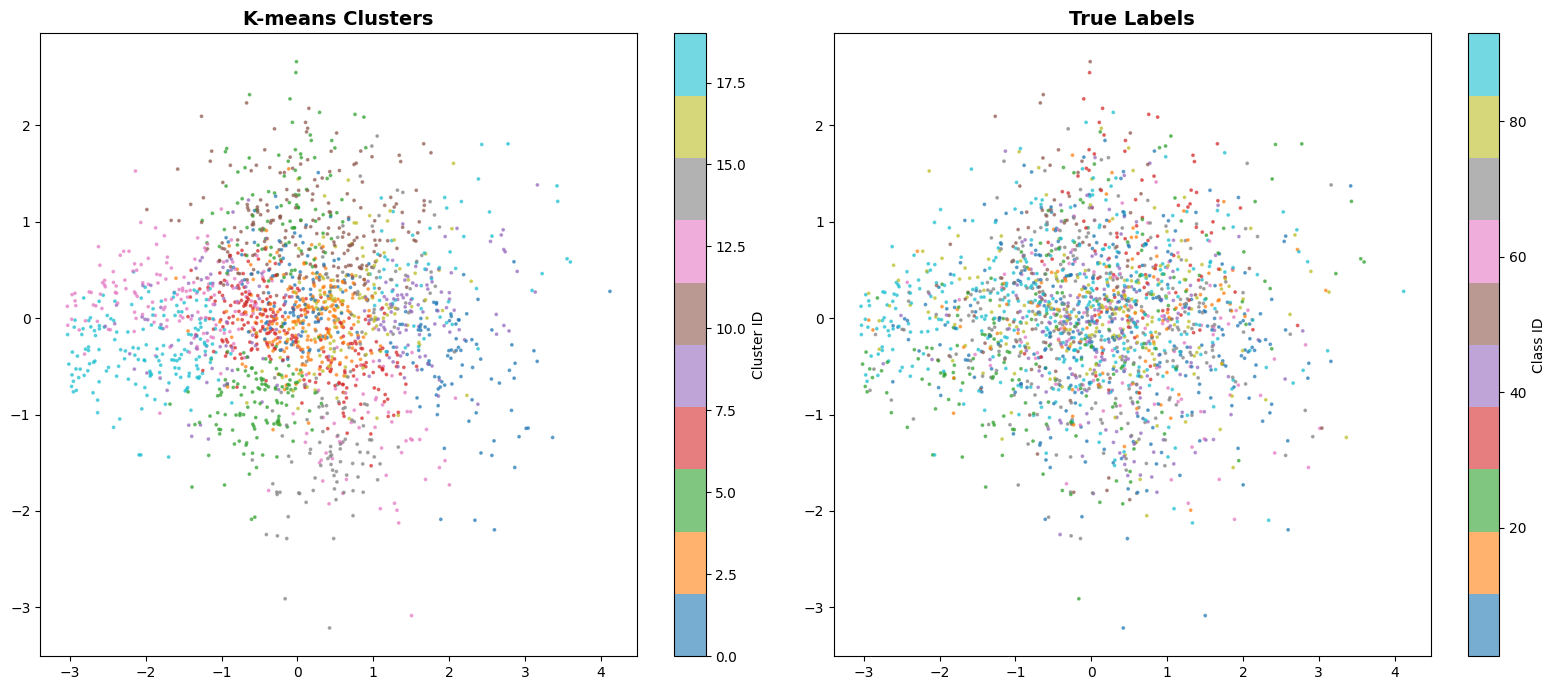

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


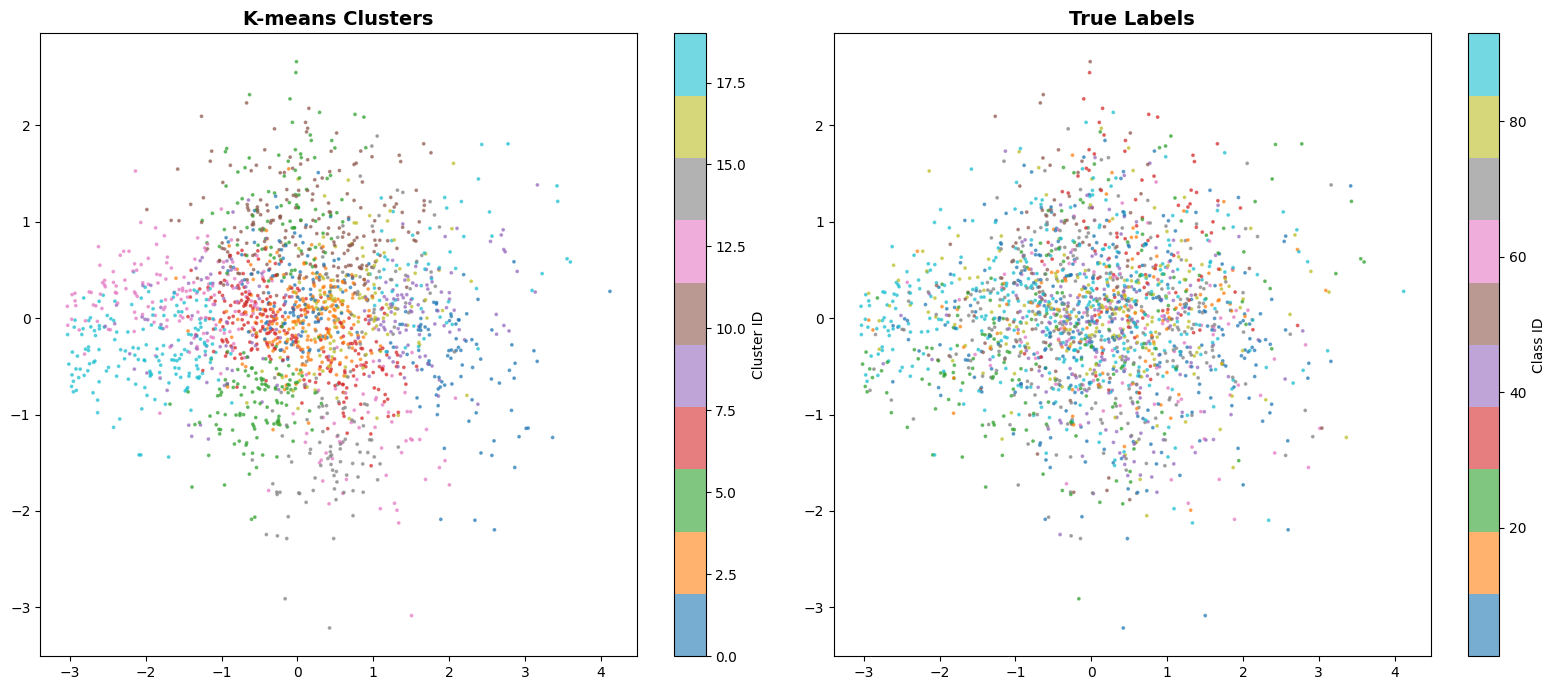

Generowanie wizualizacji t-SNE dla modelu 1...


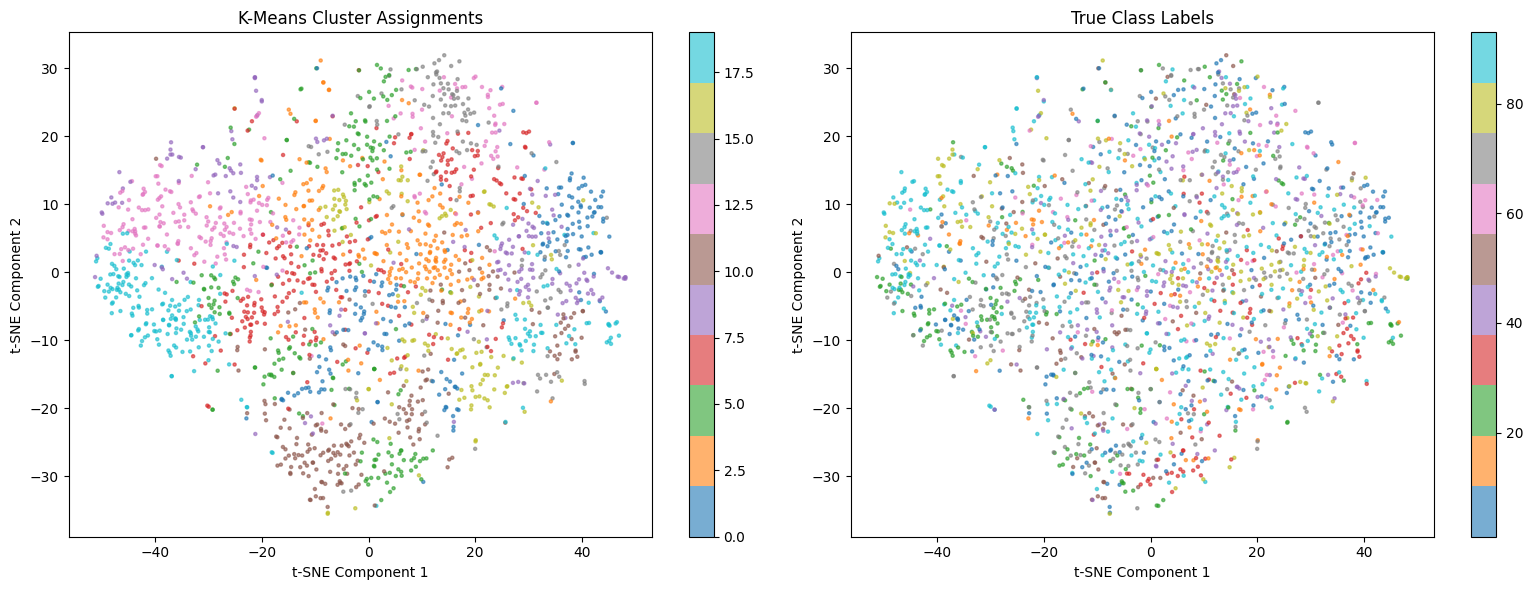

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


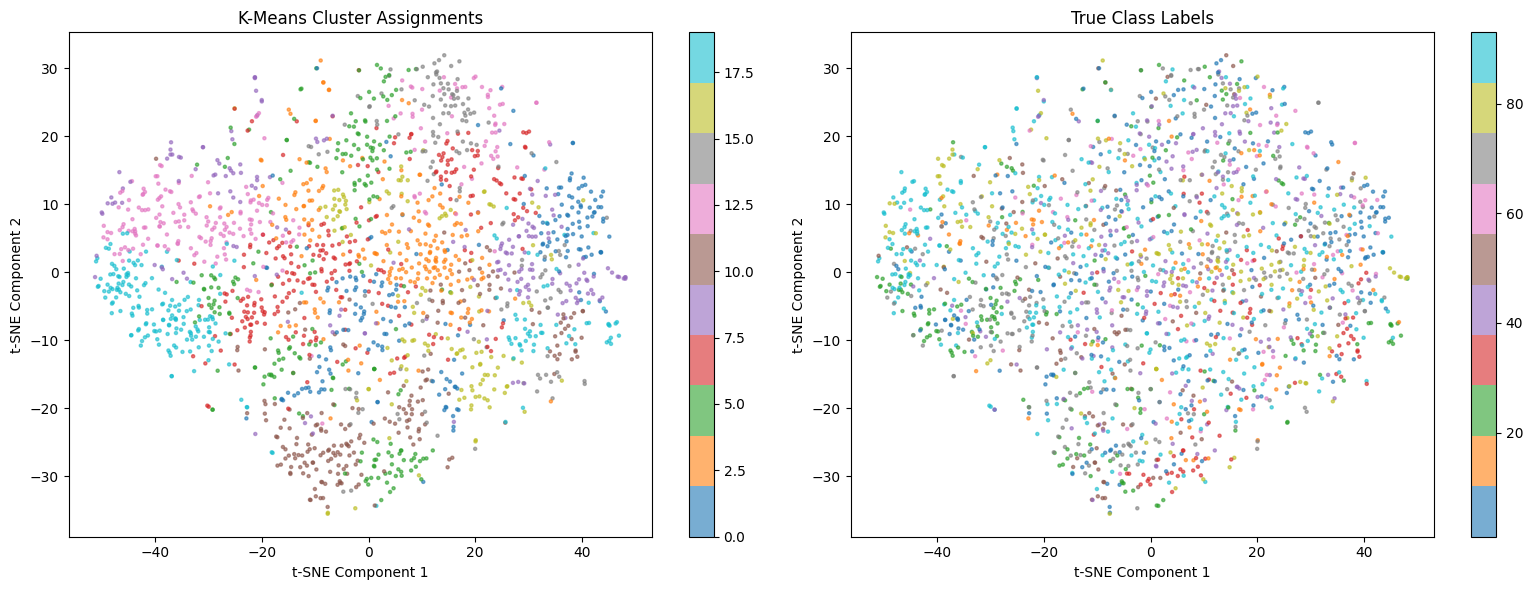


Analiza składu klastrów dla modelu 1...
Klaster 0 (rozmiar: 88):
  Klasa  1:  33 obrazów ( 37.5%)
  Klasa 64:  10 obrazów ( 11.4%)
  Klasa 93:   6 obrazów (  6.8%)
  Klasa  2:   5 obrazów (  5.7%)
  Klasa 88:   4 obrazów (  4.5%)

Klaster 1 (rozmiar: 110):
  Klasa 42:  12 obrazów ( 10.9%)
  Klasa 38:   9 obrazów (  8.2%)
  Klasa 64:   9 obrazów (  8.2%)
  Klasa 87:   9 obrazów (  8.2%)
  Klasa 69:   8 obrazów (  7.3%)

Klaster 2 (rozmiar: 138):
  Klasa 75:  19 obrazów ( 13.8%)
  Klasa 83:  19 obrazów ( 13.8%)
  Klasa 74:  17 obrazów ( 12.3%)
  Klasa 14:  15 obrazów ( 10.9%)
  Klasa 88:  11 obrazów (  8.0%)

Klaster 3 (rozmiar: 72):
  Klasa 69:   6 obrazów (  8.3%)
  Klasa 75:   6 obrazów (  8.3%)
  Klasa 88:   6 obrazów (  8.3%)
  Klasa 38:   5 obrazów (  6.9%)
  Klasa 64:   5 obrazów (  6.9%)

Klaster 4 (rozmiar: 119):
  Klasa 23:  14 obrazów ( 11.8%)
  Klasa  2:  10 obrazów (  8.4%)
  Klasa 67:  10 obrazów (  8.4%)
  Klasa 88:   9 obrazów (  7.6%)
  Klasa 69:   8 obrazów (  6.7%)

K

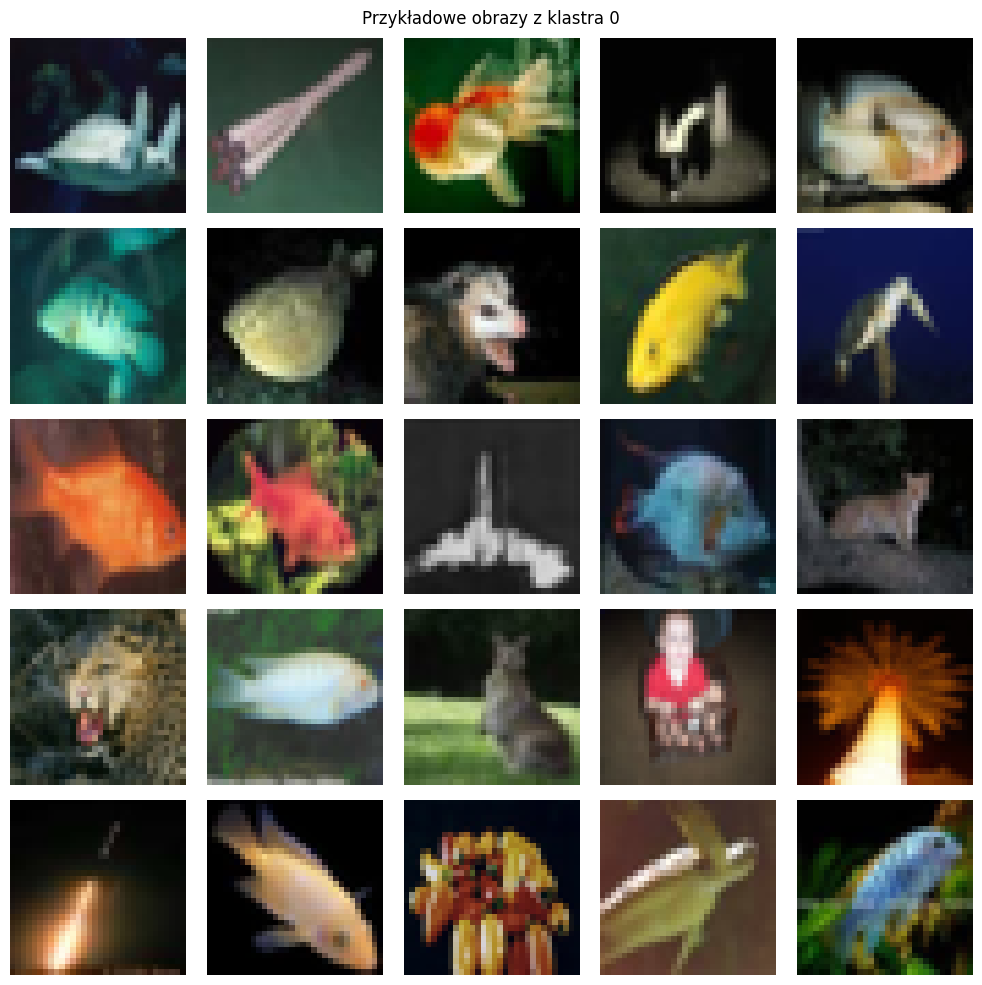


Czystość klastrów dla modelu 1...
Średnia czystość klastrów: 0.1715

Zakończono przetwarzanie modelu 1


Przetwarzanie modelu 2/5 dla 20 klas

Model załadowany
Epoka: 236
Train Loss: 0.060248
Val Loss: 0.060597
Latent Dim: 256

Używam podanych klas: [3, 39, 8, 94, 35, 69, 18, 90, 38, 20, 49, 25, 42, 81, 60, 9, 97, 52, 43, 44]
Wyciąganie cech dla modelu 2...
Features: torch.Size([64, 256])
Wyciągnięto cechy: (2000, 256)
Unikalne etykiety: [ 3  8  9 18 20 25 35 38 39 42 43 44 49 52 60 69 81 90 94 97]

Klasteryzacja dla modelu 2...
=== K-means ===
NMI (Normalized Mutual Information): 0.1914
ARI (Adjusted Rand Index): 0.0757
DBI 2.4649
Silhouette: 0.0328
Inertia: 486.21


Zapisywanie szczegółowych wyników klasteryzacji dla modelu 2...
Zapisano przypisania klastrów do: clustering_assignments_20_classes_model_2.csv
Zapisano metryki do: clustering_metrics_20_classes_model_2.csv
Generowanie wizualizacji PCA dla modelu 2...


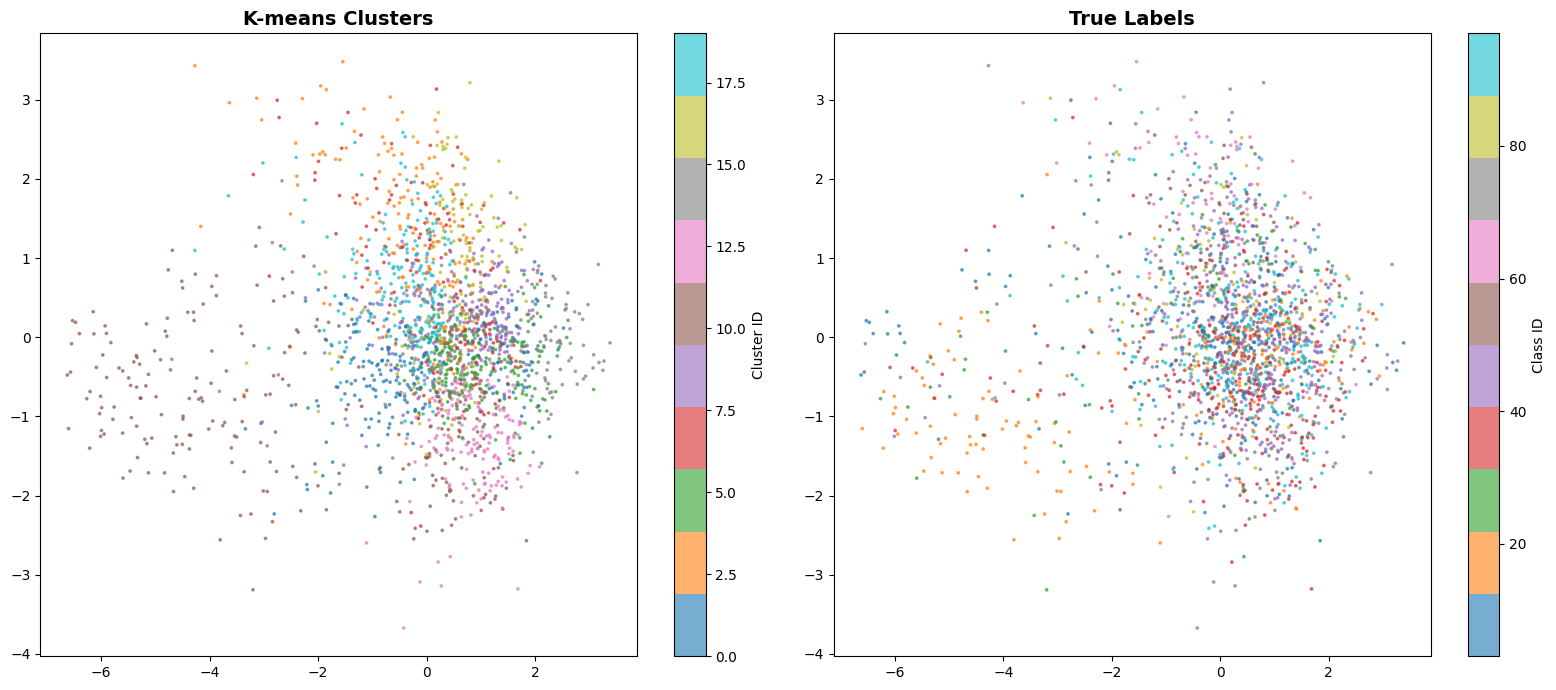

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


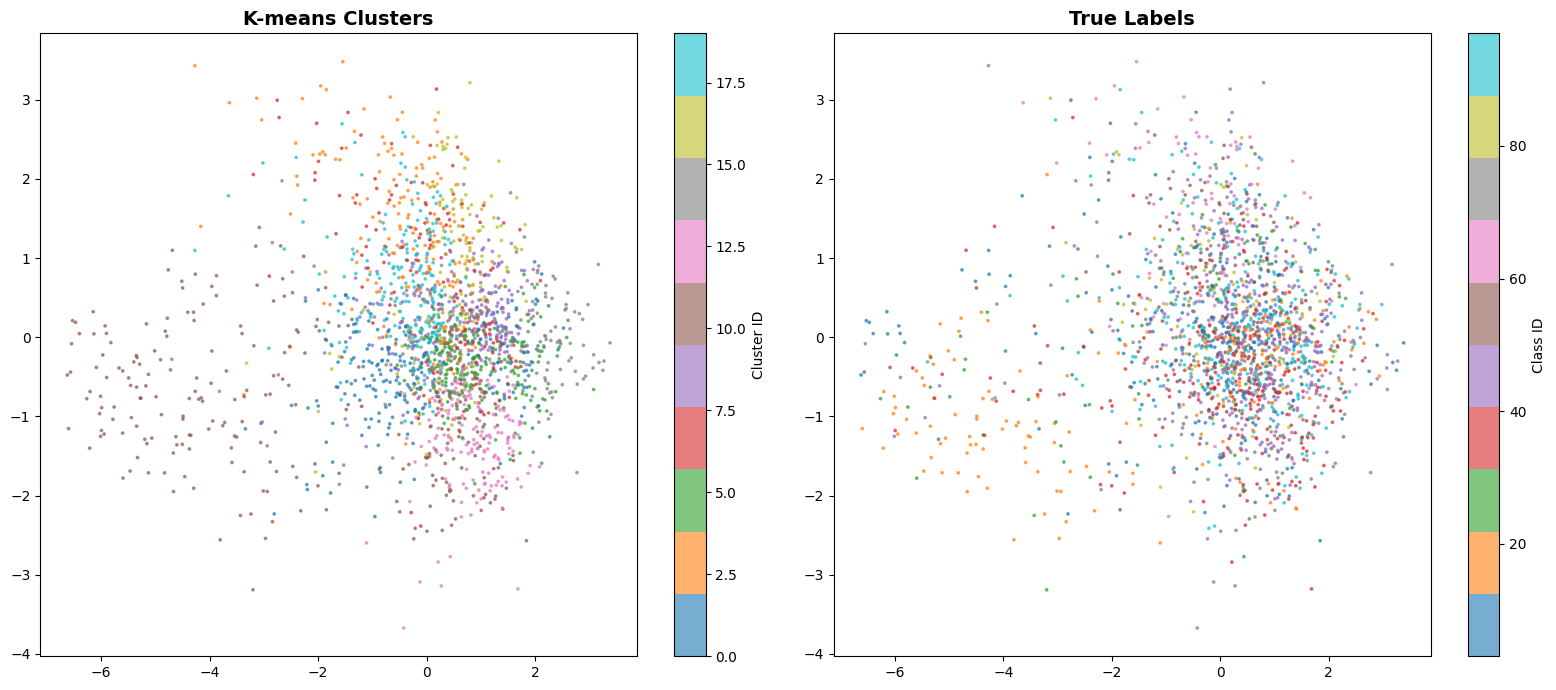

Generowanie wizualizacji t-SNE dla modelu 2...


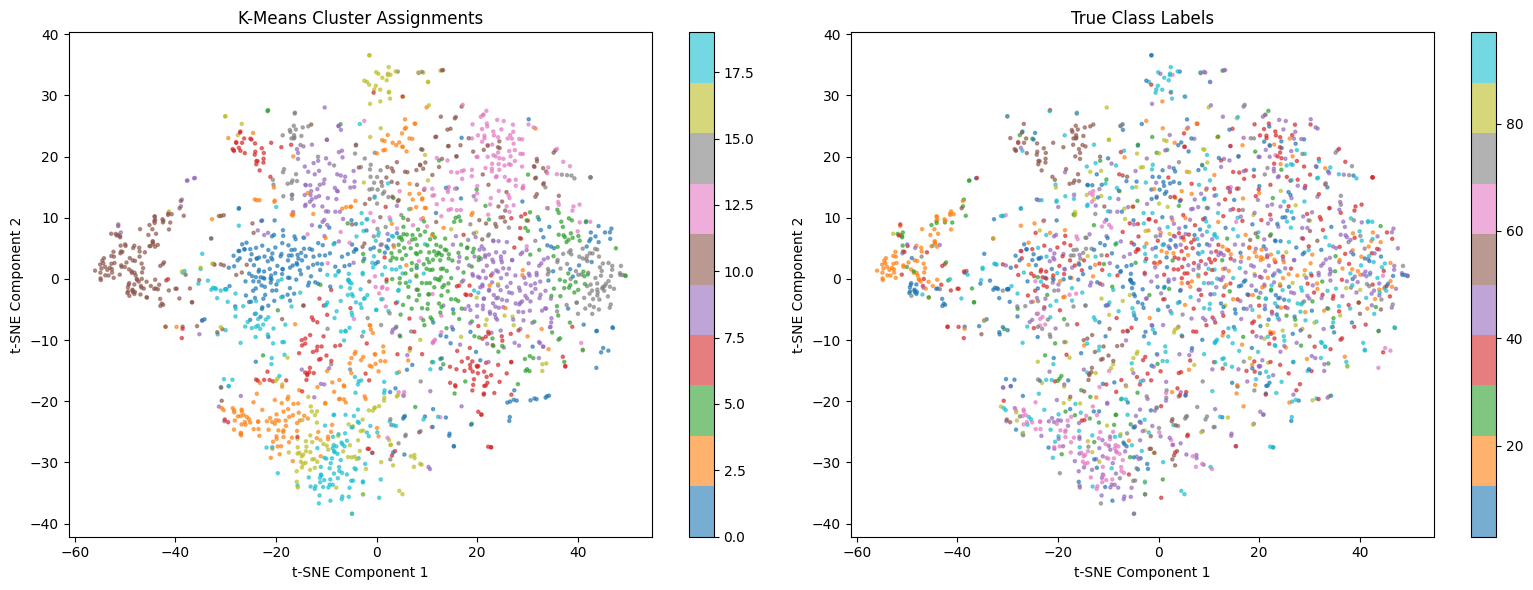

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


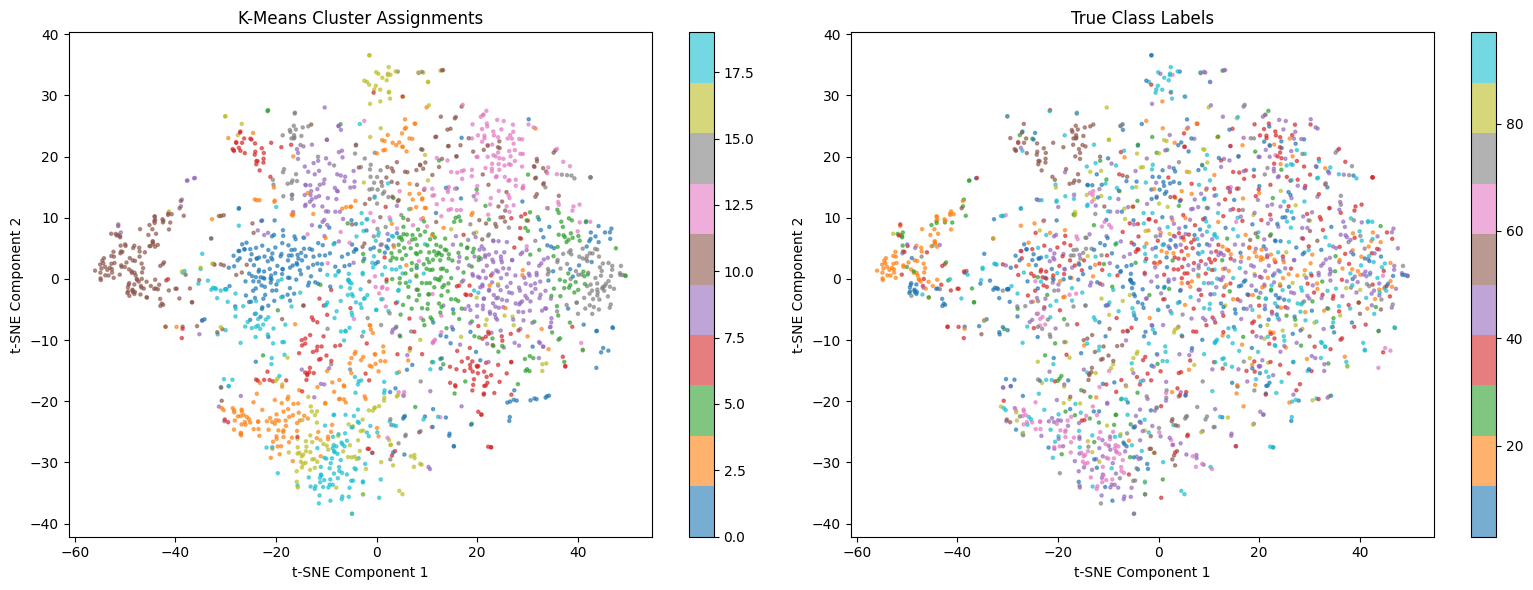


Analiza składu klastrów dla modelu 2...
Klaster 0 (rozmiar: 79):
  Klasa 97:  12 obrazów ( 15.2%)
  Klasa 18:   9 obrazów ( 11.4%)
  Klasa 39:   7 obrazów (  8.9%)
  Klasa 44:   6 obrazów (  7.6%)
  Klasa 81:   5 obrazów (  6.3%)

Klaster 1 (rozmiar: 168):
  Klasa 39:  25 obrazów ( 14.9%)
  Klasa 44:  24 obrazów ( 14.3%)
  Klasa  8:  19 obrazów ( 11.3%)
  Klasa 69:  18 obrazów ( 10.7%)
  Klasa  9:  10 obrazów (  6.0%)

Klaster 2 (rozmiar: 96):
  Klasa 81:  15 obrazów ( 15.6%)
  Klasa 39:   8 obrazów (  8.3%)
  Klasa 42:   8 obrazów (  8.3%)
  Klasa 94:   8 obrazów (  8.3%)
  Klasa 43:   7 obrazów (  7.3%)

Klaster 3 (rozmiar: 95):
  Klasa 60:  31 obrazów ( 32.6%)
  Klasa 49:  19 obrazów ( 20.0%)
  Klasa 90:  16 obrazów ( 16.8%)
  Klasa 81:   8 obrazów (  8.4%)
  Klasa 25:   6 obrazów (  6.3%)

Klaster 4 (rozmiar: 76):
  Klasa 42:  12 obrazów ( 15.8%)
  Klasa 97:  11 obrazów ( 14.5%)
  Klasa 35:   8 obrazów ( 10.5%)
  Klasa 43:   6 obrazów (  7.9%)
  Klasa 69:   6 obrazów (  7.9%)

Kla

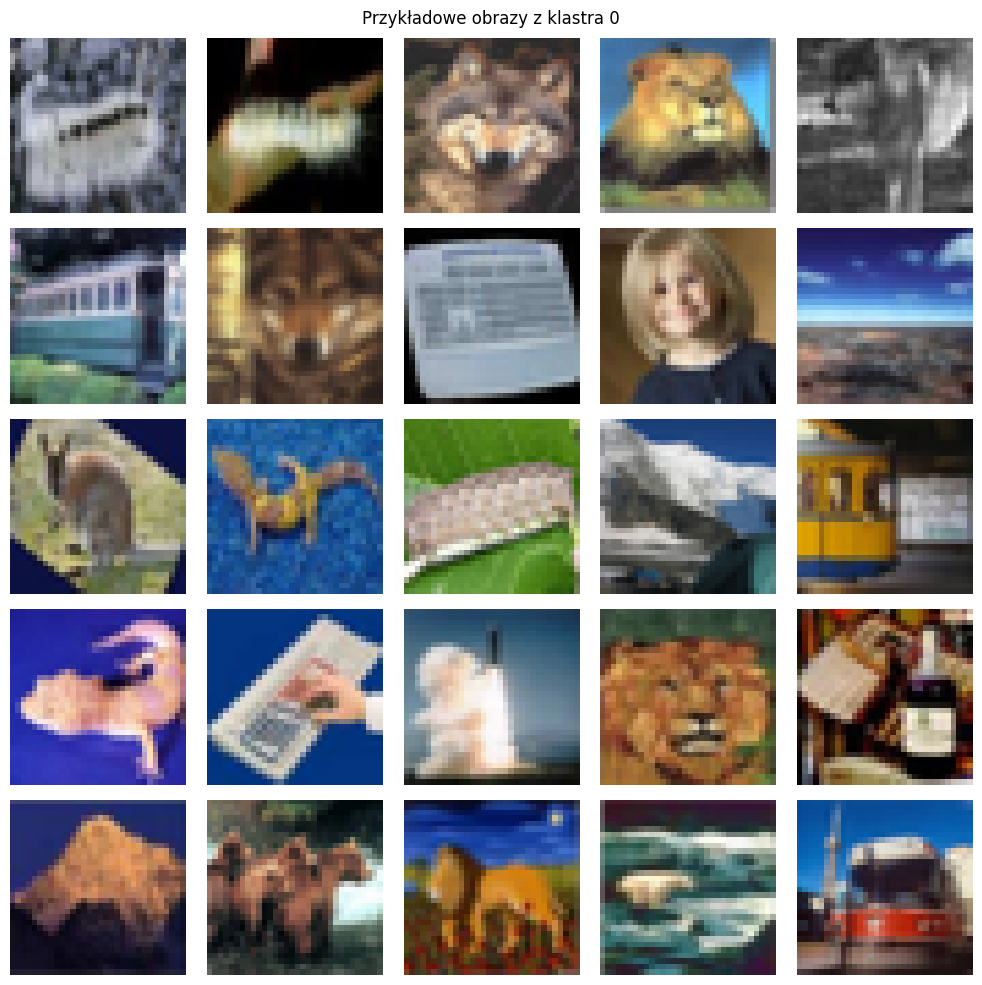


Czystość klastrów dla modelu 2...
Średnia czystość klastrów: 0.2447

Zakończono przetwarzanie modelu 2


Przetwarzanie modelu 3/5 dla 20 klas

Model załadowany
Epoka: 245
Train Loss: 0.061842
Val Loss: 0.060571
Latent Dim: 256

Używam podanych klas: [25, 56, 52, 24, 79, 26, 42, 22, 48, 33, 29, 23, 20, 74, 83, 91, 32, 15, 36, 84]
Wyciąganie cech dla modelu 3...
Features: torch.Size([64, 256])
Wyciągnięto cechy: (2000, 256)
Unikalne etykiety: [15 20 22 23 24 25 26 29 32 33 36 42 48 52 56 74 79 83 84 91]

Klasteryzacja dla modelu 3...
=== K-means ===
NMI (Normalized Mutual Information): 0.1616
ARI (Adjusted Rand Index): 0.0596
DBI 2.5110
Silhouette: 0.0515
Inertia: 430.98


Zapisywanie szczegółowych wyników klasteryzacji dla modelu 3...
Zapisano przypisania klastrów do: clustering_assignments_20_classes_model_3.csv
Zapisano metryki do: clustering_metrics_20_classes_model_3.csv
Generowanie wizualizacji PCA dla modelu 3...


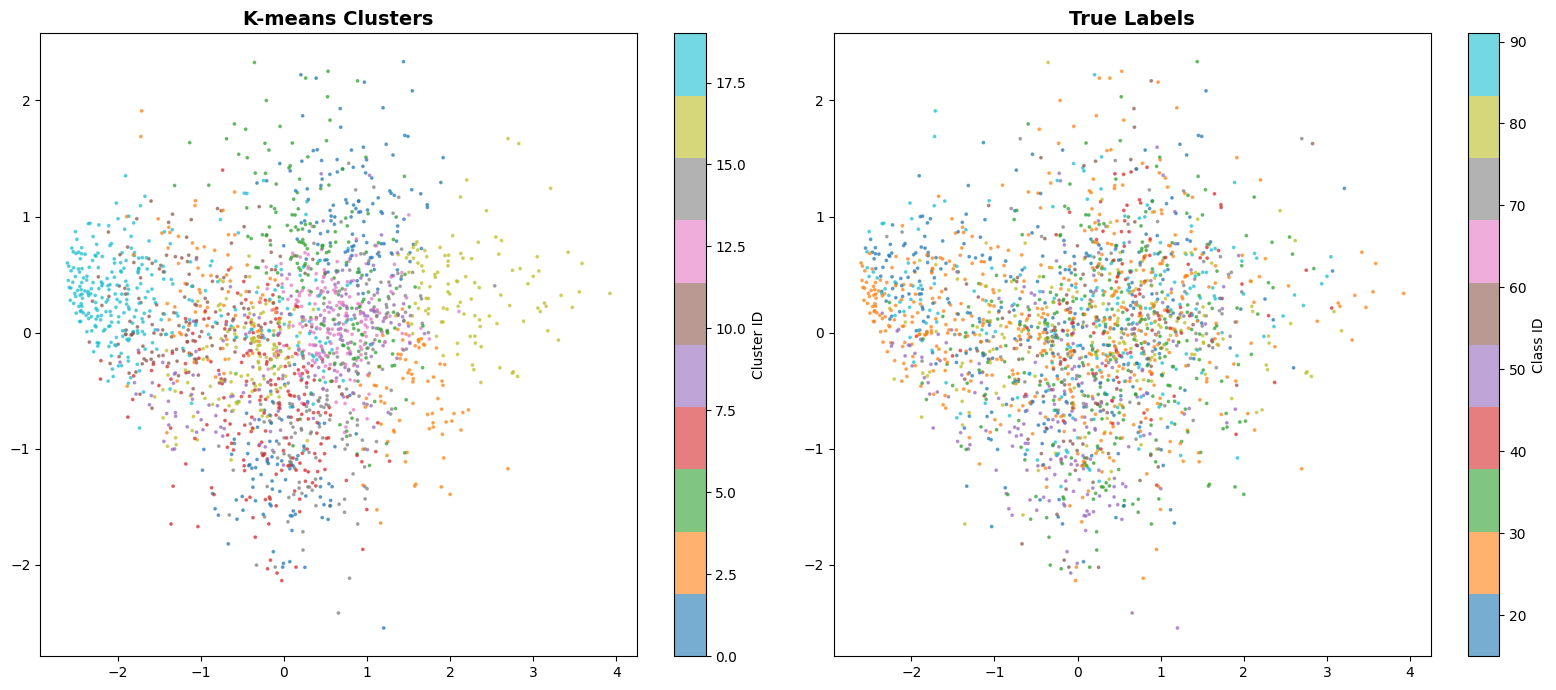

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


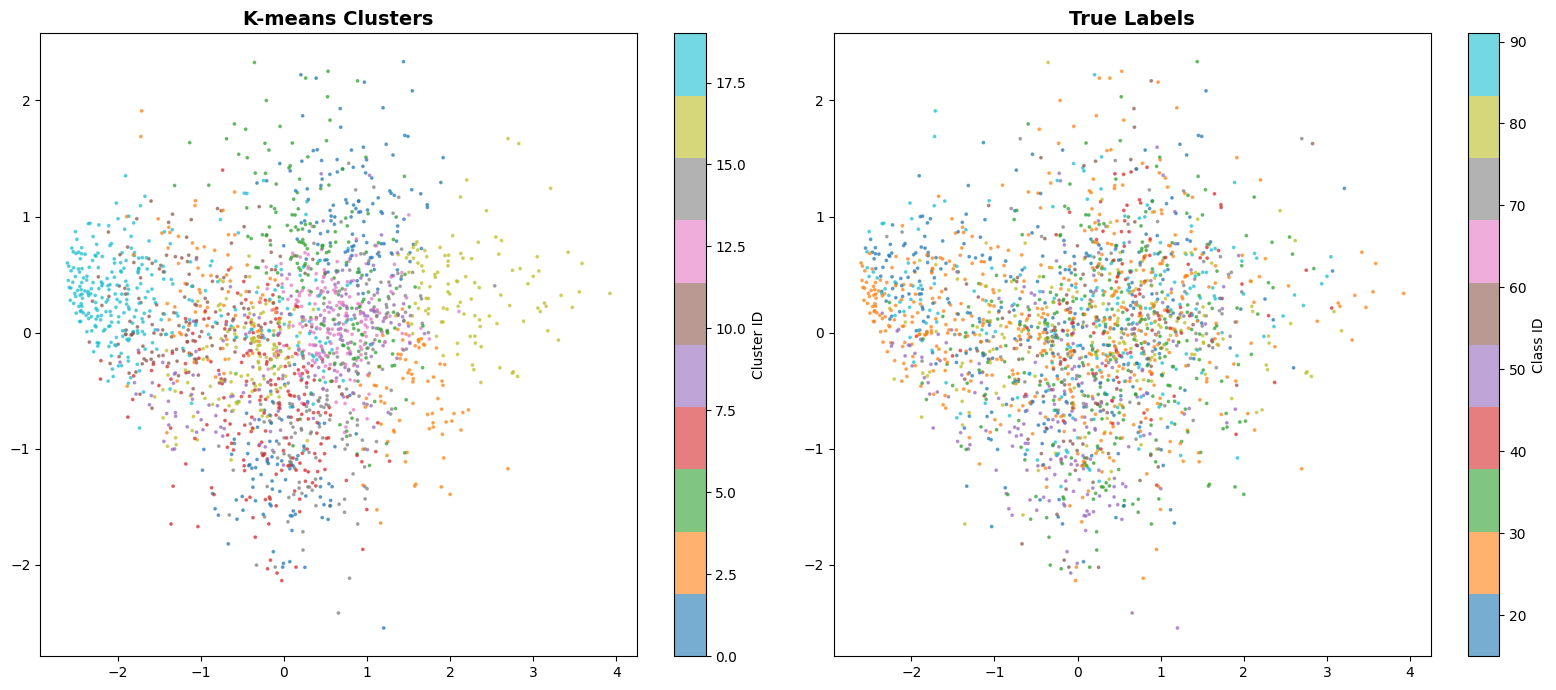

Generowanie wizualizacji t-SNE dla modelu 3...


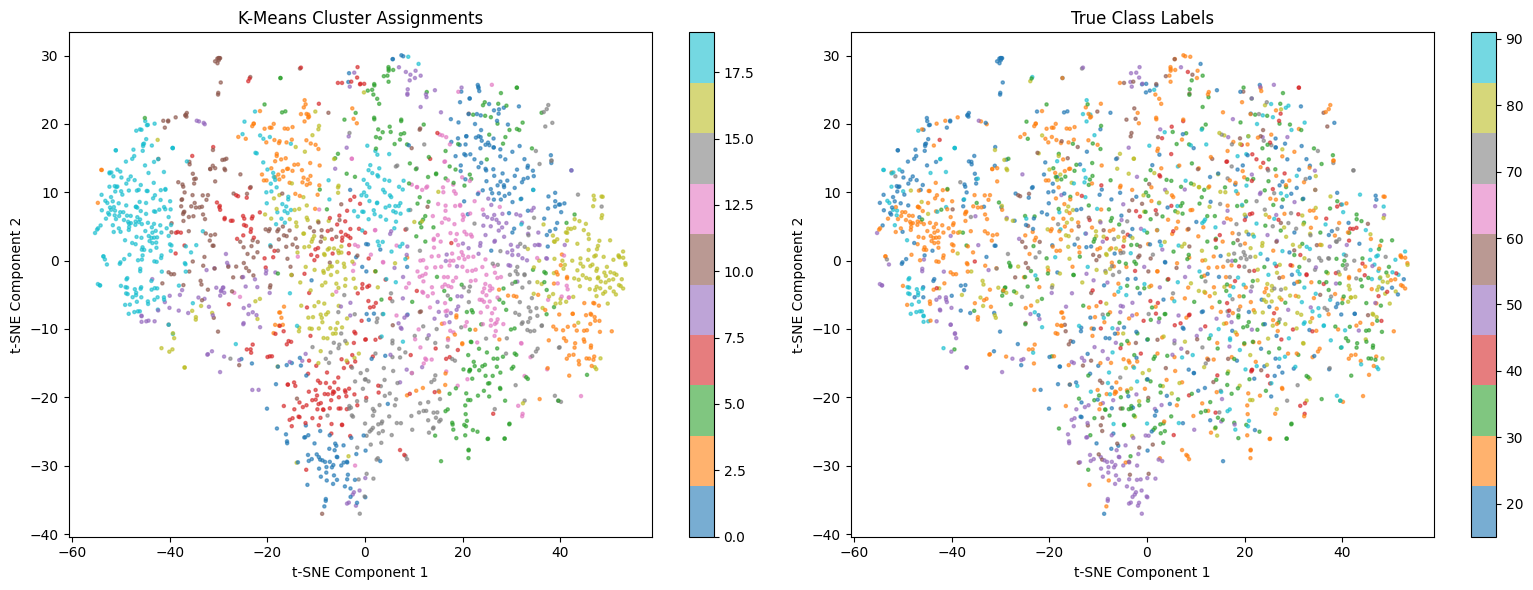

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


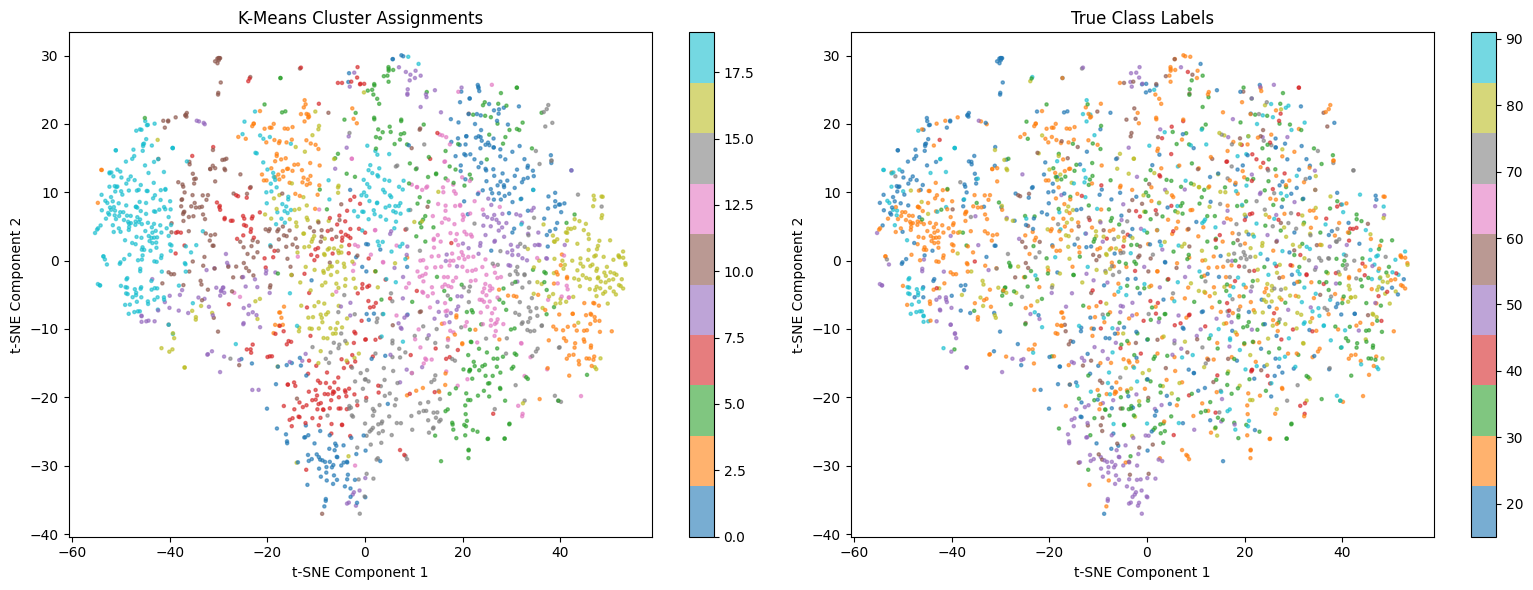


Analiza składu klastrów dla modelu 3...
Klaster 0 (rozmiar: 85):
  Klasa 52:  49 obrazów ( 57.6%)
  Klasa 56:  10 obrazów ( 11.8%)
  Klasa 32:   5 obrazów (  5.9%)
  Klasa 29:   5 obrazów (  5.9%)
  Klasa 15:   4 obrazów (  4.7%)

Klaster 1 (rozmiar: 121):
  Klasa 15:  17 obrazów ( 14.0%)
  Klasa 42:  15 obrazów ( 12.4%)
  Klasa 74:  11 obrazów (  9.1%)
  Klasa 84:  11 obrazów (  9.1%)
  Klasa 36:   9 obrazów (  7.4%)

Klaster 2 (rozmiar: 75):
  Klasa 33:  25 obrazów ( 33.3%)
  Klasa 25:   7 obrazów (  9.3%)
  Klasa 26:   5 obrazów (  6.7%)
  Klasa 23:   4 obrazów (  5.3%)
  Klasa 83:   4 obrazów (  5.3%)

Klaster 3 (rozmiar: 81):
  Klasa 23:  33 obrazów ( 40.7%)
  Klasa 36:  12 obrazów ( 14.8%)
  Klasa 84:   9 obrazów ( 11.1%)
  Klasa 56:   5 obrazów (  6.2%)
  Klasa 22:   4 obrazów (  4.9%)

Klaster 4 (rozmiar: 97):
  Klasa 36:  20 obrazów ( 20.6%)
  Klasa 23:  17 obrazów ( 17.5%)
  Klasa 22:   6 obrazów (  6.2%)
  Klasa 15:   6 obrazów (  6.2%)
  Klasa 56:   6 obrazów (  6.2%)

Kla

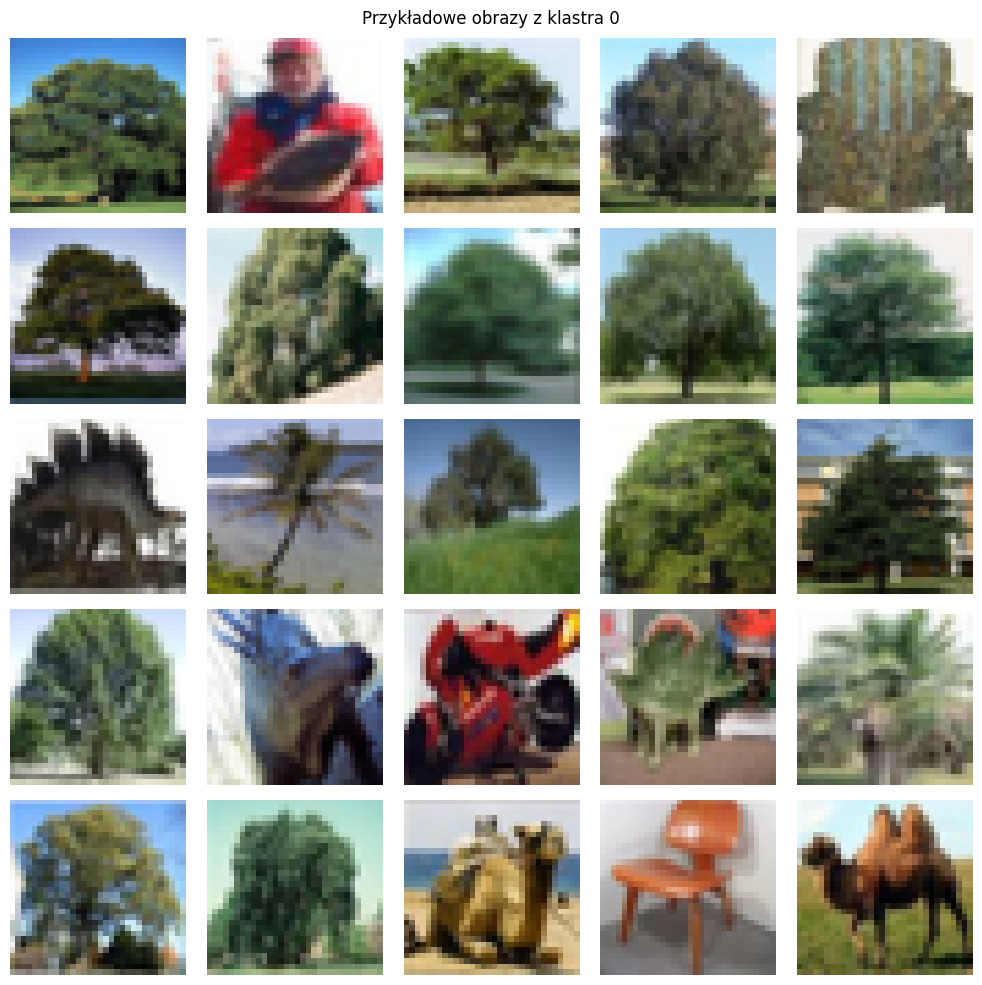


Czystość klastrów dla modelu 3...
Średnia czystość klastrów: 0.2328

Zakończono przetwarzanie modelu 3


Przetwarzanie modelu 4/5 dla 20 klas

Model załadowany
Epoka: 222
Train Loss: 0.064072
Val Loss: 0.065355
Latent Dim: 256

Używam podanych klas: [54, 72, 84, 26, 40, 93, 71, 45, 34, 21, 6, 5, 4, 70, 22, 35, 11, 60, 86, 78]
Wyciąganie cech dla modelu 4...
Features: torch.Size([64, 256])
Wyciągnięto cechy: (2000, 256)
Unikalne etykiety: [ 4  5  6 11 21 22 26 34 35 40 45 54 60 70 71 72 78 84 86 93]

Klasteryzacja dla modelu 4...
=== K-means ===
NMI (Normalized Mutual Information): 0.1390
ARI (Adjusted Rand Index): 0.0434
DBI 2.3921
Silhouette: 0.0405
Inertia: 465.22


Zapisywanie szczegółowych wyników klasteryzacji dla modelu 4...
Zapisano przypisania klastrów do: clustering_assignments_20_classes_model_4.csv
Zapisano metryki do: clustering_metrics_20_classes_model_4.csv
Generowanie wizualizacji PCA dla modelu 4...


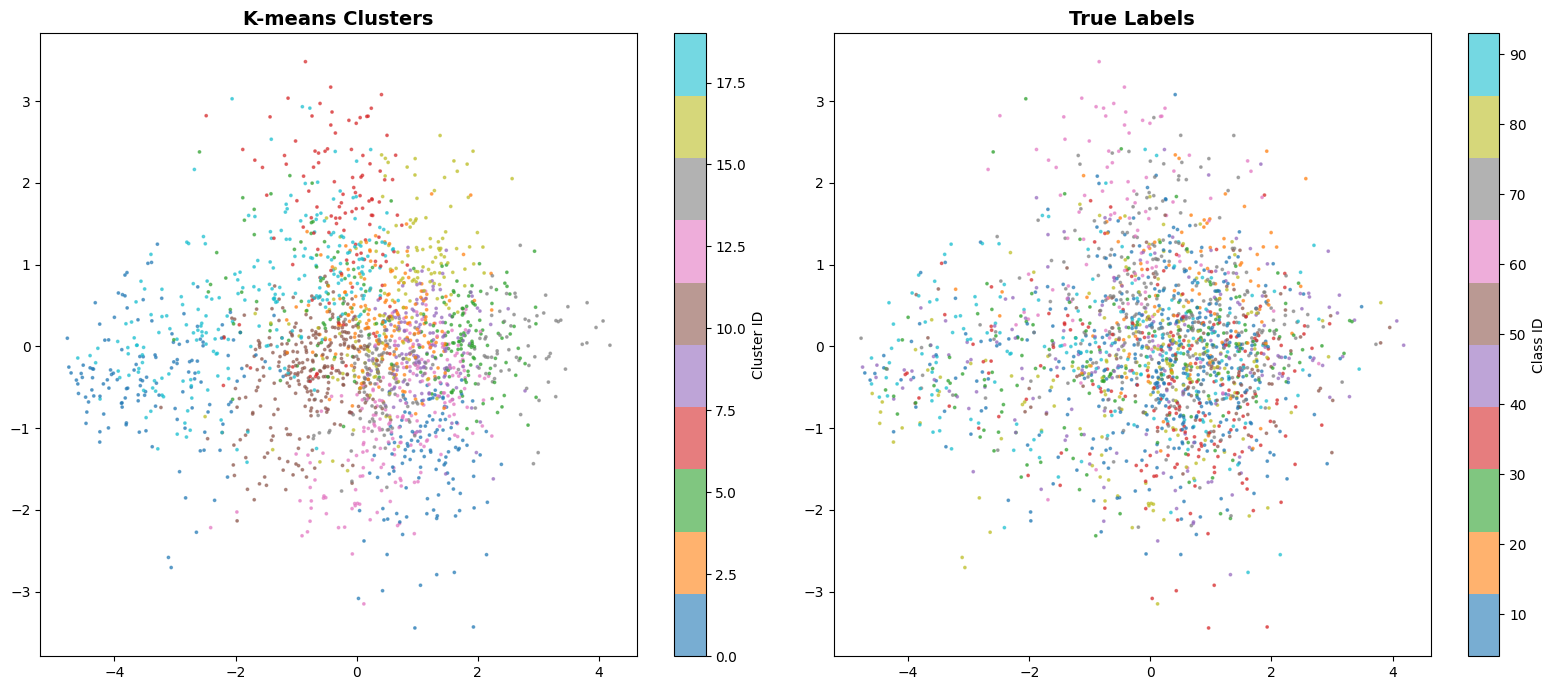

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


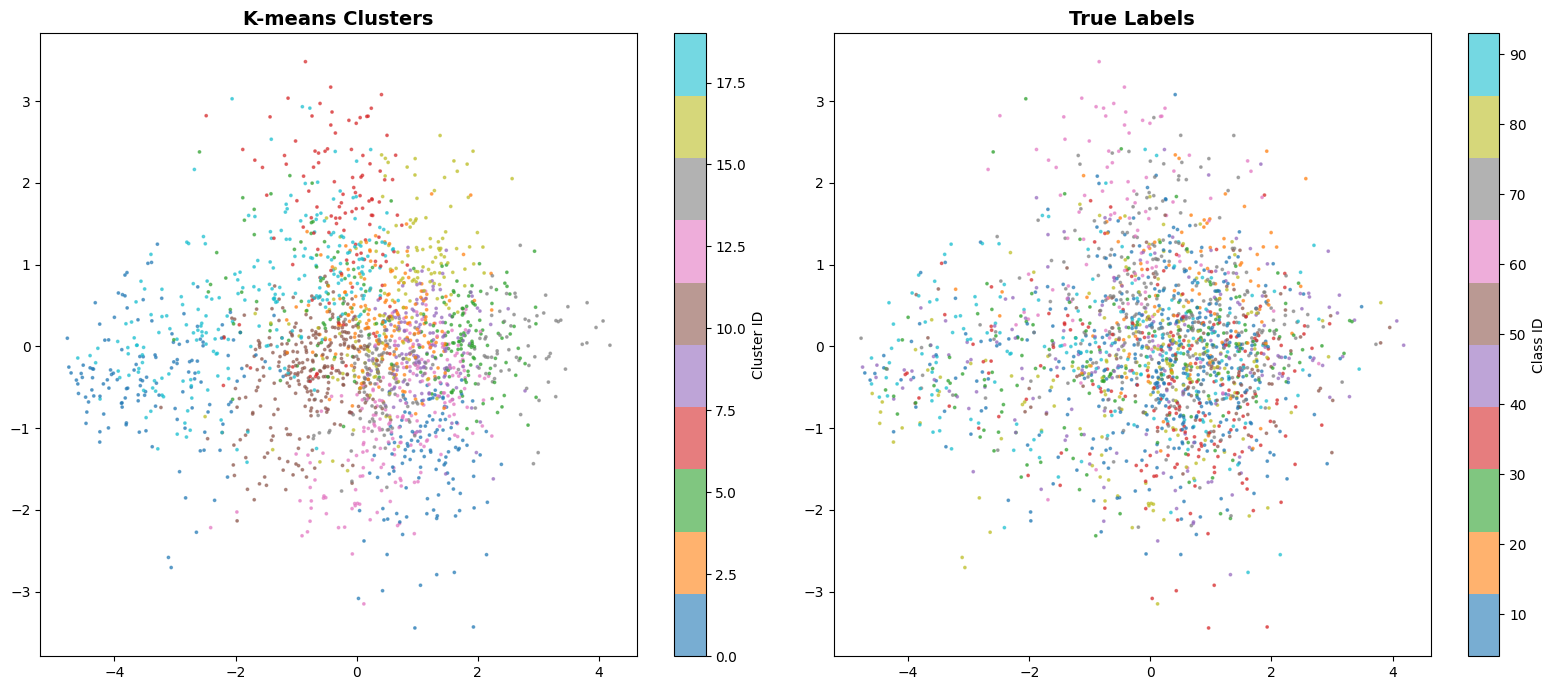

Generowanie wizualizacji t-SNE dla modelu 4...


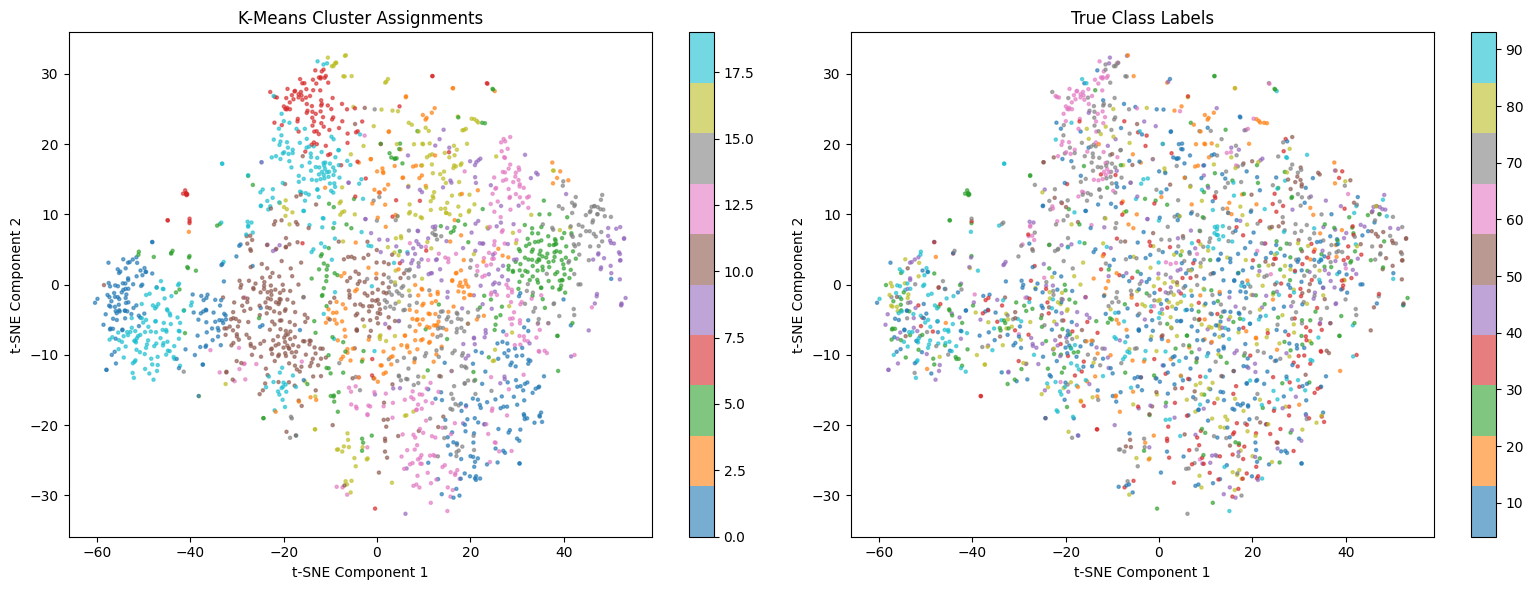

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


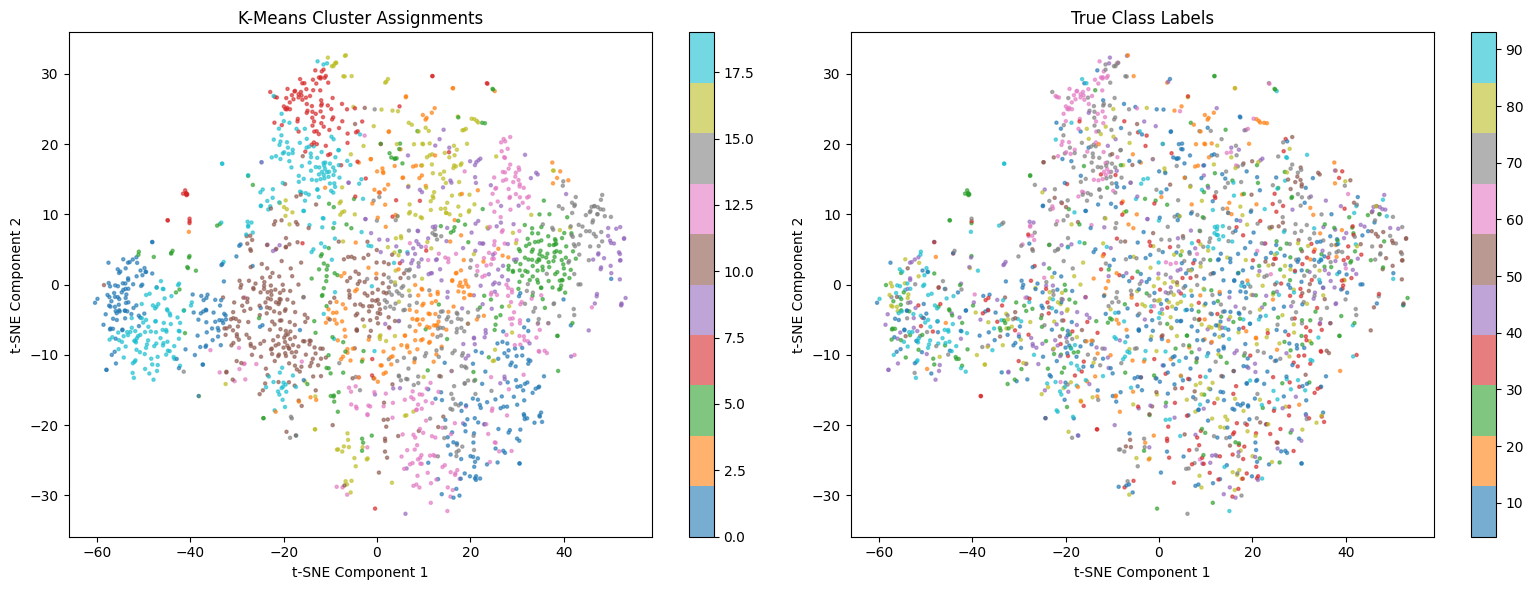


Analiza składu klastrów dla modelu 4...
Klaster 0 (rozmiar: 136):
  Klasa 86:  22 obrazów ( 16.2%)
  Klasa 84:  15 obrazów ( 11.0%)
  Klasa 40:  13 obrazów (  9.6%)
  Klasa 22:  12 obrazów (  8.8%)
  Klasa 35:   9 obrazów (  6.6%)

Klaster 1 (rozmiar: 120):
  Klasa 34:  20 obrazów ( 16.7%)
  Klasa  6:  19 obrazów ( 15.8%)
  Klasa 35:  11 obrazów (  9.2%)
  Klasa 11:  10 obrazów (  8.3%)
  Klasa 45:   8 obrazów (  6.7%)

Klaster 2 (rozmiar: 96):
  Klasa  4:  12 obrazów ( 12.5%)
  Klasa 21:  11 obrazów ( 11.5%)
  Klasa 78:  10 obrazów ( 10.4%)
  Klasa 26:   8 obrazów (  8.3%)
  Klasa 93:   7 obrazów (  7.3%)

Klaster 3 (rozmiar: 73):
  Klasa 21:  12 obrazów ( 16.4%)
  Klasa 11:   9 obrazów ( 12.3%)
  Klasa  5:   6 obrazów (  8.2%)
  Klasa  4:   6 obrazów (  8.2%)
  Klasa  6:   6 obrazów (  8.2%)

Klaster 4 (rozmiar: 80):
  Klasa 21:  16 obrazów ( 20.0%)
  Klasa 11:  12 obrazów ( 15.0%)
  Klasa 86:  10 obrazów ( 12.5%)
  Klasa 72:   7 obrazów (  8.8%)
  Klasa 22:   6 obrazów (  7.5%)

Kl

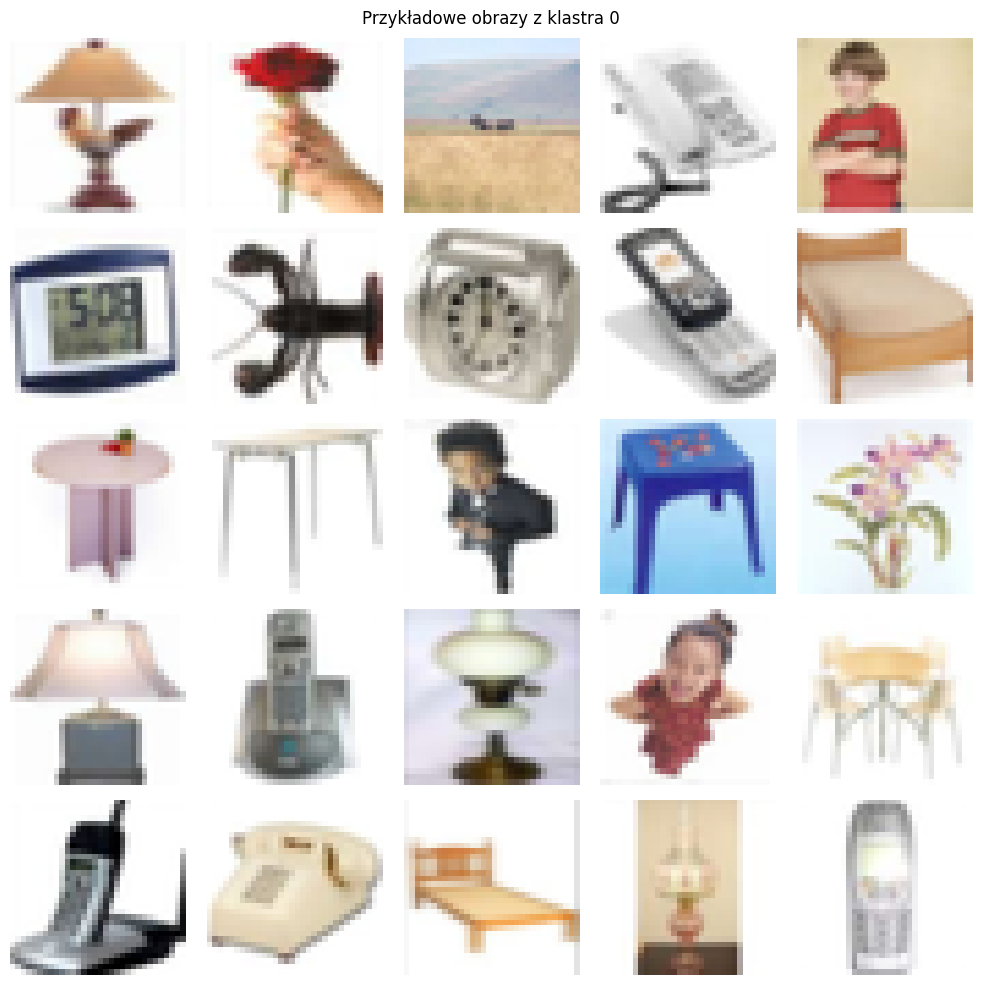


Czystość klastrów dla modelu 4...
Średnia czystość klastrów: 0.2100

Zakończono przetwarzanie modelu 4


Przetwarzanie modelu 5/5 dla 20 klas

Model załadowany
Epoka: 247
Train Loss: 0.063046
Val Loss: 0.062364
Latent Dim: 256

Używam podanych klas: [61, 66, 89, 60, 20, 15, 14, 92, 32, 3, 24, 13, 1, 34, 23, 55, 82, 7, 76, 25]
Wyciąganie cech dla modelu 5...
Features: torch.Size([64, 256])
Wyciągnięto cechy: (2000, 256)
Unikalne etykiety: [ 1  3  7 13 14 15 20 23 24 25 32 34 55 60 61 66 76 82 89 92]

Klasteryzacja dla modelu 5...
=== K-means ===
NMI (Normalized Mutual Information): 0.1644
ARI (Adjusted Rand Index): 0.0585
DBI 2.4711
Silhouette: 0.0294
Inertia: 401.03


Zapisywanie szczegółowych wyników klasteryzacji dla modelu 5...
Zapisano przypisania klastrów do: clustering_assignments_20_classes_model_5.csv
Zapisano metryki do: clustering_metrics_20_classes_model_5.csv
Generowanie wizualizacji PCA dla modelu 5...


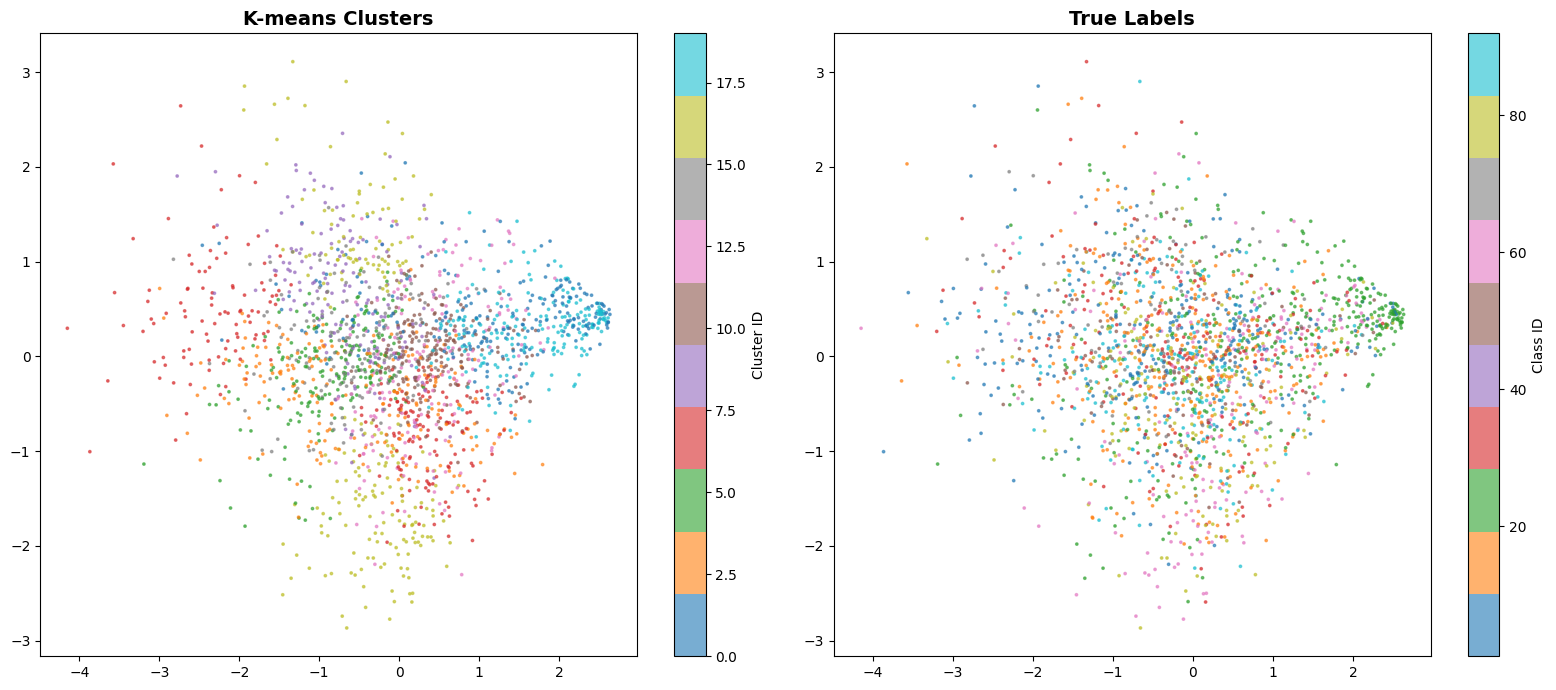

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


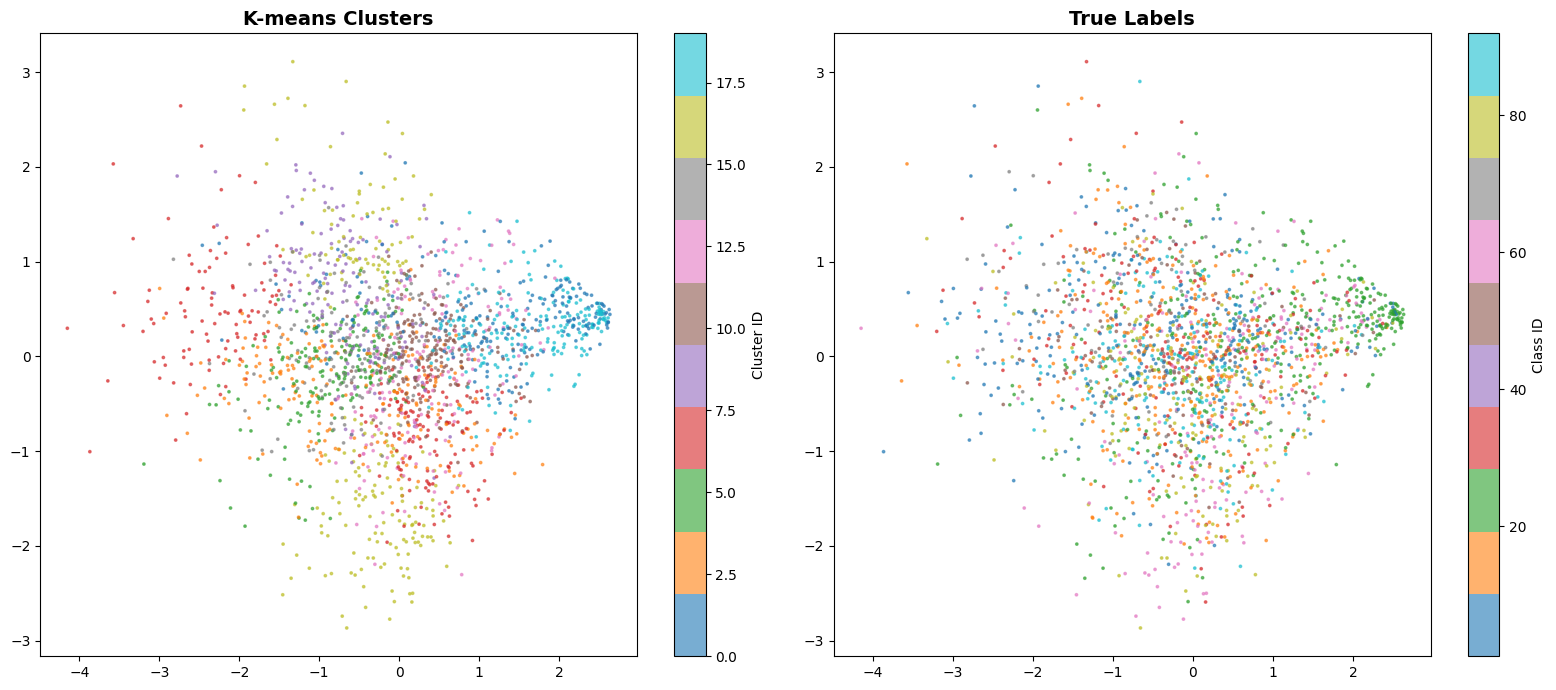

Generowanie wizualizacji t-SNE dla modelu 5...


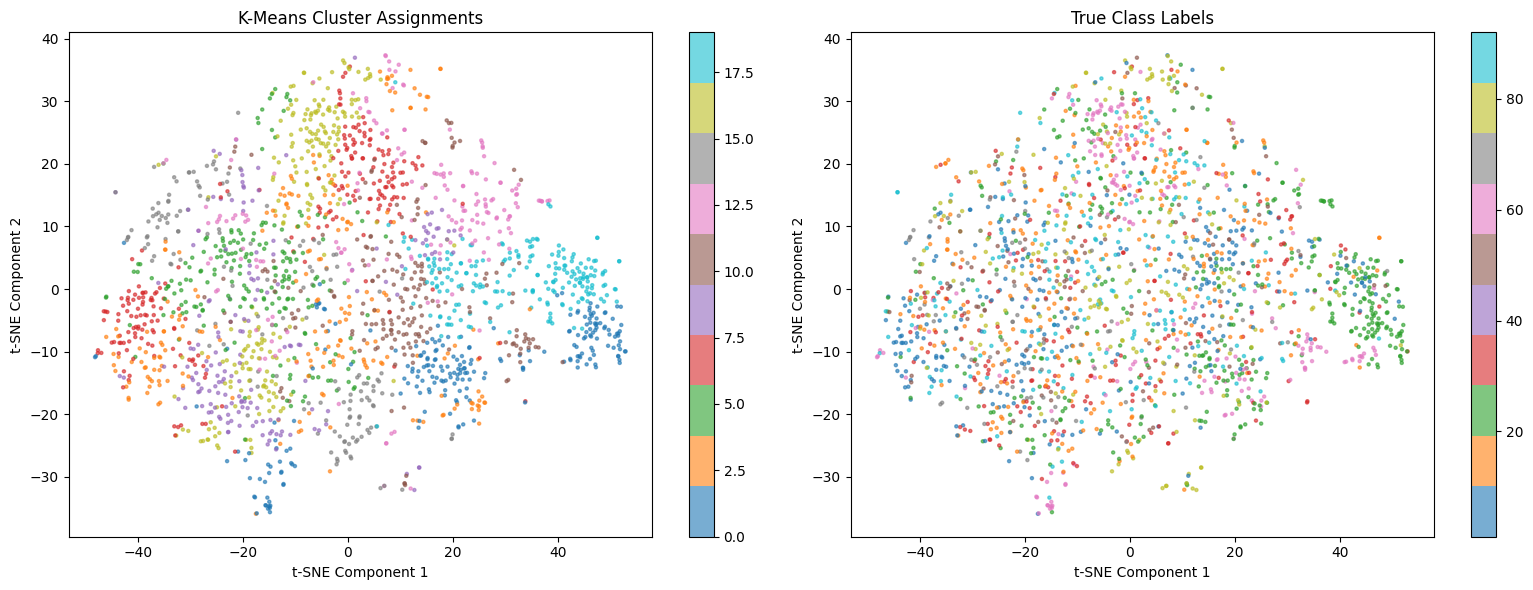

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


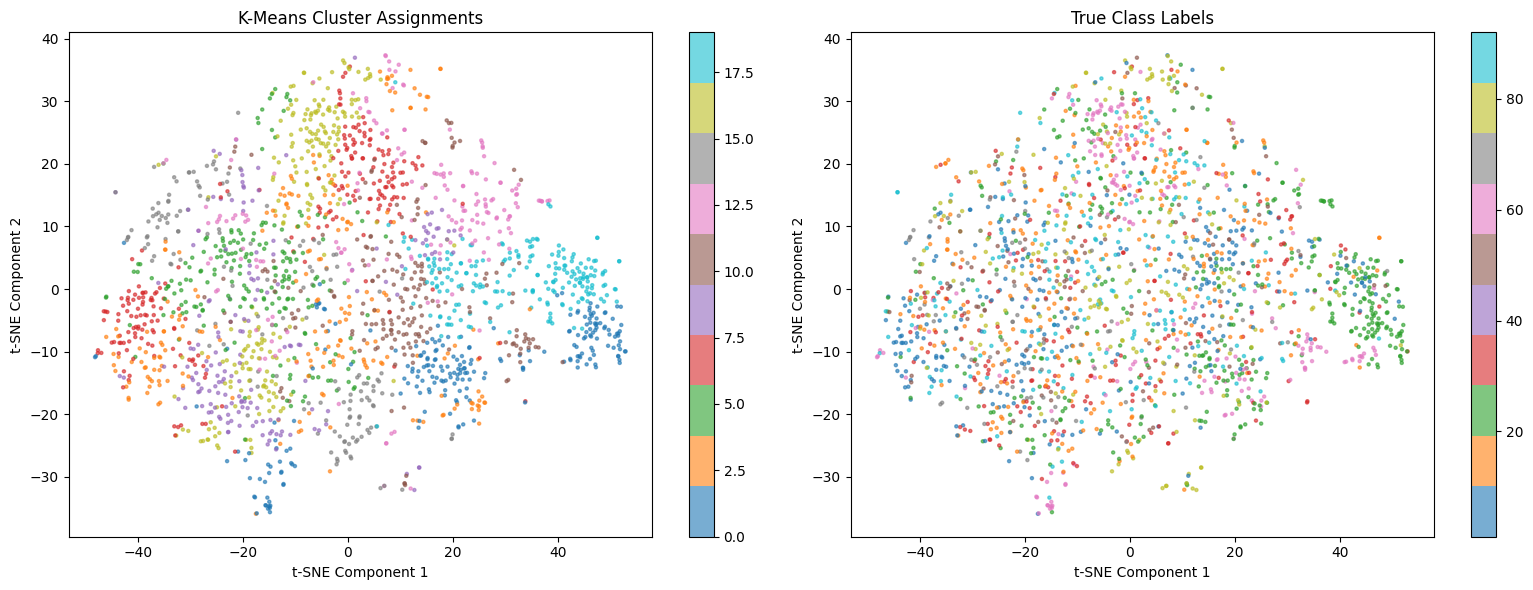


Analiza składu klastrów dla modelu 5...
Klaster 0 (rozmiar: 57):
  Klasa 61:  21 obrazów ( 36.8%)
  Klasa 66:   5 obrazów (  8.8%)
  Klasa 92:   5 obrazów (  8.8%)
  Klasa 23:   4 obrazów (  7.0%)
  Klasa 82:   4 obrazów (  7.0%)

Klaster 1 (rozmiar: 175):
  Klasa 20:  41 obrazów ( 23.4%)
  Klasa 61:  30 obrazów ( 17.1%)
  Klasa 23:  25 obrazów ( 14.3%)
  Klasa 24:  17 obrazów (  9.7%)
  Klasa 25:  12 obrazów (  6.9%)

Klaster 2 (rozmiar: 102):
  Klasa 92:  21 obrazów ( 20.6%)
  Klasa  1:  20 obrazów ( 19.6%)
  Klasa 14:  11 obrazów ( 10.8%)
  Klasa 23:   8 obrazów (  7.8%)
  Klasa 82:   7 obrazów (  6.9%)

Klaster 3 (rozmiar: 106):
  Klasa 76:  24 obrazów ( 22.6%)
  Klasa 23:  17 obrazów ( 16.0%)
  Klasa 60:  14 obrazów ( 13.2%)
  Klasa 55:   8 obrazów (  7.5%)
  Klasa 92:   6 obrazów (  5.7%)

Klaster 4 (rozmiar: 95):
  Klasa 55:  12 obrazów ( 12.6%)
  Klasa 25:  10 obrazów ( 10.5%)
  Klasa 92:   9 obrazów (  9.5%)
  Klasa  1:   7 obrazów (  7.4%)
  Klasa 82:   6 obrazów (  6.3%)

K

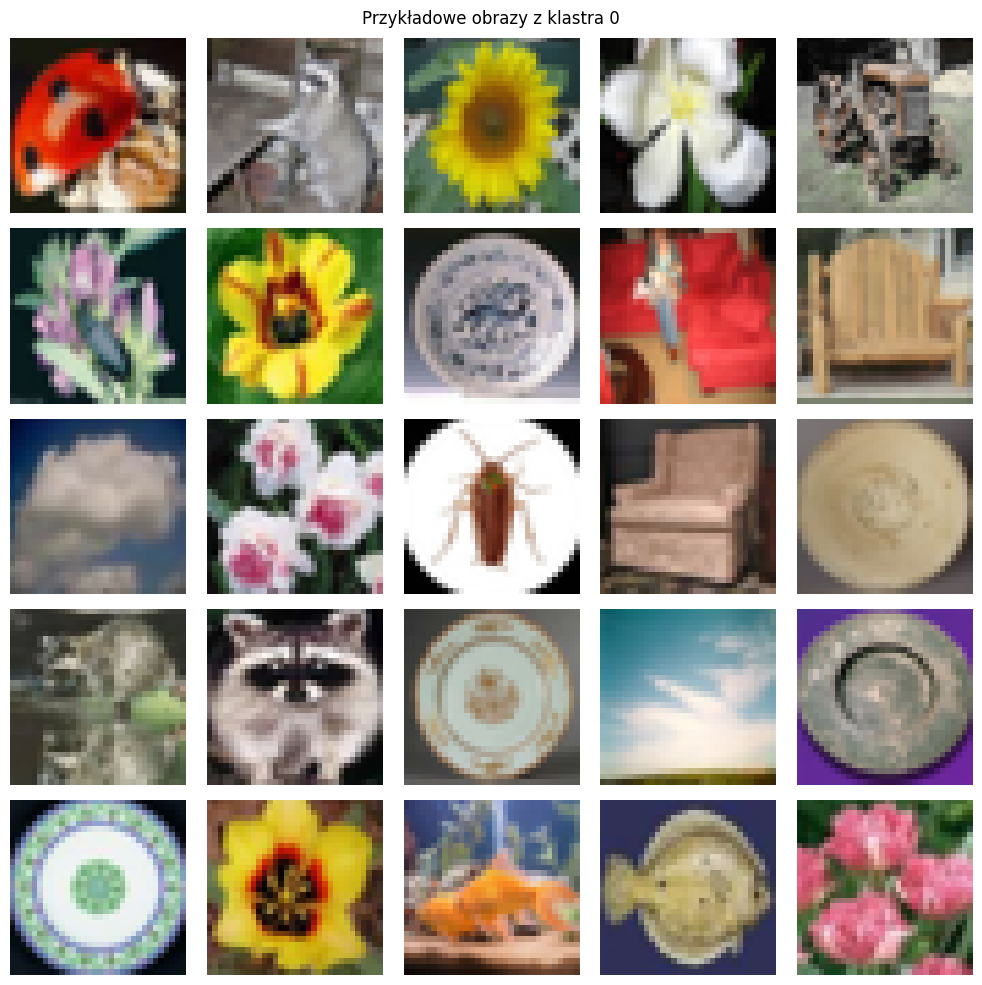


Czystość klastrów dla modelu 5...
Średnia czystość klastrów: 0.2010

Zakończono przetwarzanie modelu 5


Zapisywanie zbiorczych wyników...

PODSUMOWANIE WSZYSTKICH 5 MODELI (20 KLAS)
        nmi       ari  silhouette       dbi  n_clusters     inertia  model_id  n_classes    purity
0  0.126741  0.038368    0.036994  2.602984          20  400.835846         1         20  0.171513
1  0.191430  0.075744    0.032830  2.464912          20  486.209869         2         20  0.244671
2  0.161607  0.059618    0.051538  2.510953          20  430.980469         3         20  0.232768
3  0.139009  0.043386    0.040513  2.392099          20  465.221527         4         20  0.209961
4  0.164380  0.058530    0.029438  2.471121          20  401.029785         5         20  0.200974

STATYSTYKI
NMI - średnia: 0.1566, std: 0.0250
ARI - średnia: 0.0551, std: 0.0148
Silhouette - średnia: 0.0383, std: 0.0085
DBI - średnia: 2.4884, std: 0.0771
Inertia - średnia: 436.86, std: 38.26

Wszystkie wyniki zapisan

In [17]:
import os
import pandas as pd


model_configs = [
    {'path': '../training_results/masked_autoencoder/cifar100/20_classes/masked_autoencoder_cifar100_best_20260114_005637.pt', 'n_clusters': 20, 'model_id': 1},
    {'path': '../training_results/masked_autoencoder/cifar100/20_classes/masked_autoencoder_cifar100_best_20260114_102215.pt', 'n_clusters': 20, 'model_id': 2},
    {'path': '../training_results/masked_autoencoder/cifar100/20_classes/masked_autoencoder_cifar100_best_20260114_105303.pt', 'n_clusters': 20, 'model_id': 3},
    {'path': '../training_results/masked_autoencoder/cifar100/20_classes/masked_autoencoder_cifar100_best_20260114_111514.pt', 'n_clusters': 20, 'model_id': 4},
    {'path': '../training_results/masked_autoencoder/cifar100/20_classes/masked_autoencoder_cifar100_best_20260114_113611.pt', 'n_clusters': 20, 'model_id': 5},
]


BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'masked_autoencoder', 'cifar100', '20_classes')
os.makedirs(save_dir, exist_ok=True)


batch_size = 64


all_results = []


for config in model_configs:
    model_path = config['path']
    n_clusters = config['n_clusters']
    model_id = config['model_id']

    print(f"\n{'='*80}")
    print(f"Przetwarzanie modelu {model_id}/{len(model_configs)} dla {n_clusters} klas")
    print(f"{'='*80}\n")


    model, checkpoint = load_trained_model(model_path, model_type='autoencoder')
    selected_classes = checkpoint.get('selected_classes', None)


    _, _, _, _, test_loader = create_and_load_subset(
        n_clusters,
        batch_size=batch_size,
        seed=42,
        selected_classes=selected_classes
    )


    print(f"Wyciąganie cech dla modelu {model_id}...")
    features, labels = extract_features(model, test_loader)
    print(f"Unikalne etykiety: {np.unique(labels)}")


    cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)


    metrics['model_id'] = model_id
    metrics['n_classes'] = n_clusters
    all_results.append(metrics)


    clustering_results = pd.DataFrame({
        'sample_id': range(len(cluster_ids)),
        'true_label': labels,
        'predicted_cluster': cluster_ids
    })


    clustering_csv_filename = f'clustering_assignments_{n_clusters}_classes_model_{model_id}.csv'
    clustering_csv_path = os.path.join(save_dir, clustering_csv_filename)
    clustering_results.to_csv(clustering_csv_path, index=False)

    metrics_csv_filename = f'clustering_metrics_{n_clusters}_classes_model_{model_id}.csv'
    metrics_csv_path = os.path.join(save_dir, metrics_csv_filename)
    metrics_df = pd.DataFrame([metrics])
    metrics_df.to_csv(metrics_csv_path, index=False)


    print(f"Generowanie wizualizacji PCA dla modelu {model_id}...")
    pca_filename = f'clusters_pca_{n_clusters}_classes_model_{model_id}'
    pca_path_png = os.path.join(save_dir, f'{pca_filename}.png')
    pca_path_eps = os.path.join(save_dir, f'{pca_filename}.eps')

    visualize_clusters(features, cluster_ids, labels, pca_path_png)
    visualize_clusters(features, cluster_ids, labels, pca_path_eps)

    print(f"Generowanie wizualizacji t-SNE dla modelu {model_id}...")
    tsne_filename = f'clusters_tsne_{n_clusters}_classes_model_{model_id}'
    tsne_path_png = os.path.join(save_dir, f'{tsne_filename}.png')
    tsne_path_eps = os.path.join(save_dir, f'{tsne_filename}.eps')

    visualize_clusters_tsne(features, cluster_ids, labels, tsne_path_png)
    visualize_clusters_tsne(features, cluster_ids, labels, tsne_path_eps)


    print(f"\nAnaliza składu klastrów dla modelu {model_id}...")
    analyze_cluster_composition(cluster_ids, labels, n_clusters)

    print(f"\nWizualizacja próbek klastrów dla modelu {model_id}...")
    visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)

    print(f"\nCzystość klastrów dla modelu {model_id}...")
    purity = cluster_purity(cluster_ids, labels)

    if purity is not None:
        metrics['purity'] = purity





summary_results_df = pd.DataFrame(all_results)
summary_csv_path = os.path.join(save_dir, f'all_models_summary_{n_clusters}_classes.csv')
summary_results_df.to_csv(summary_csv_path, index=False)

print("\n" + "="*80)
print(f"PODSUMOWANIE WSZYSTKICH {len(model_configs)} MODELI ({n_clusters} KLAS)")
print("="*80)
print(summary_results_df.to_string())

print("\n" + "="*80)

print(f"NMI - średnia: {summary_results_df['nmi'].mean():.4f}, std: {summary_results_df['nmi'].std():.4f}")
print(f"ARI - średnia: {summary_results_df['ari'].mean():.4f}, std: {summary_results_df['ari'].std():.4f}")
print(f"Silhouette - średnia: {summary_results_df['silhouette'].mean():.4f}, std: {summary_results_df['silhouette'].std():.4f}")
print(f"DBI - średnia: {summary_results_df['dbi'].mean():.4f}, std: {summary_results_df['dbi'].std():.4f}")
print(f"Inertia - średnia: {summary_results_df['inertia'].mean():.2f}, std: {summary_results_df['inertia'].std():.2f}")

print(f"\nWszystkie wyniki zapisane w: {save_dir}")
